In [ ]:
!pip install optuna

In [ ]:
# Tratamiento de datos
# ==============================================================================
!pip install optuna --quiet
import numpy as np
import pandas as pd
import statsmodels.api as sm

# Gráficos
# ==============================================================================
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['font.size'] = 8

# Preprocesado y modelado
# ==============================================================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import ParameterGrid
from sklearn.inspection import permutation_importance
from joblib import Parallel, delayed
import optuna

# Configuración warnings
# ==============================================================================
import warnings

# Descarga de datos
# ==============================================================================
url = ('/content/drive/MyDrive/csv/Archivos finales/Finales codificados/Archivos sin columnas altamente correlacionadas/COMPLETOVM_sincolumnas_altamentecorrelacionadas.csv'
)

# columnas a excluir del análisis (por índice)
idx_excluir = [0,1]

datos = pd.read_csv(url, sep=',')

# Store original X and Y for final output
# Using .copy() to avoid SettingWithCopyWarning later
columnas_originales = datos.iloc[:, idx_excluir].copy()
columnas_originales.columns = ['X_original', 'Y_original'] # Rename for clarity

display(datos.head())
display(datos.info())

# --- Diagnóstico de la columna 'Zonrecdesc' antes de la transformación ---
print("\n--- Análisis de la columna 'Zonrecdesc' antes de la transformación ---")
print(datos['Zonrecdesc'].value_counts())
print("----------------------------------------------------------------------\n")

# Usar np.isclose para comparación de floats para la creación de 'recarga'
datos['recarga'] = np.where(np.isclose(datos['Zonrecdesc'], -0.771575), 1, 0)
# Diagnóstico adicional para la columna 'recarga' después de la transformación
print("--- Análisis de la columna 'recarga' después de la transformación ---")
print(datos['recarga'].value_counts())
print("----------------------------------------------------------------------\n")

# Una vez creada la nueva variable respuesta se descarta la original
datos = datos.drop(columns = 'Zonrecdesc')

# Exclude columns 0 and 1 (X and Y) for model training
# The 'X' and 'Y' columns are at index 0 and 1 after read_csv, so drop by name or index
# Assuming they are named 'X' and 'Y' as per the .info() output
datos_modelo = datos.drop(columns=datos.columns[idx_excluir])


# División de los datos en entrenamiento y test
# ==============================================================================
X_train, X_test, y_train, y_test = train_test_split(
                                        datos_modelo.drop(columns="recarga"), # Use datos_modelo here
                                        datos_modelo['recarga'],             # Use datos_modelo here
                                        test_size = 0.25,
                                        #random_state = 123,
                                        stratify=datos_modelo['recarga']     # Use datos_modelo here
                                    )

print(f"Tamaño conjunto entrenamiento: {X_train.shape[0]}")
print(f"Tamaño conjunto test: {X_test.shape[0]}")

print(f"Balance de clases entrenamiento: {y_train.value_counts()}")
print(f"Balance de clases test: {y_test.value_counts()}")

# Grid de hiperparámetros evaluados
# ==============================================================================
param_grid = ParameterGrid(
                {'n_estimators': [100,300,500],
                 'max_features': [13,16,20,'sqrt'],
                 'max_depth'   : [None, 10, 20,30],
                 'criterion'   : ['gini', 'entropy']
                }
            )

# Loop para ajustar un modelo con cada combinación de hiperparámetros
# ==============================================================================
resultados = {'params': [], 'oob_accuracy': []}

for params in param_grid:

    modelo = RandomForestClassifier(
                oob_score    = True,
                n_jobs        = -1,
                #random_state = 123,
                ** params
             )

    modelo.fit(X_train, y_train)

    resultados['params'].append(params)
    resultados['oob_accuracy'].append(modelo.oob_score_)
    print(f"Modelo: {params} \u2713")

# Resultados
# ==============================================================================
resultados = pd.DataFrame(resultados)
resultados = pd.concat([resultados, resultados['params'].apply(pd.Series)], axis=1)
resultados = resultados.sort_values('oob_accuracy', ascending=False)
resultados = resultados.drop(columns='params')
resultados.head()

# Mejores hiperparámetros por out-of-bag error
# ==============================================================================
print("--------------------------------------------------")
print("Mejores hiperparámetros encontrados (oob-accuracy)")
print("--------------------------------------------------")
print(resultados.iloc[0,0:])


# Extraer mejores hiperparámetros
# ==============================================================================
mejores_params = resultados.iloc[0]

# Handle max_depth being NaN (from original None) in case it was the best param
max_depth_val = int(mejores_params['max_depth']) if pd.notna(mejores_params['max_depth']) else None

# Modelo con los mejores hiperparámetros
# ==============================================================================
modelo_final = RandomForestClassifier(
    n_estimators=int(mejores_params['n_estimators']),
    max_features=mejores_params['max_features'],
    max_depth=max_depth_val,
    criterion=mejores_params['criterion'],
    oob_score=True,
    n_jobs=-1,
    #random_state=123
)

# Entrenamiento del modelo final
# ==============================================================================
modelo_final.fit(X_train, y_train)


# Error de test del modelo final
# ==============================================================================
predicciones = modelo_final.predict(X=X_test)
predicciones

# Matriz de confusión
# ==============================================================================
mat_confusion = confusion_matrix(y_true=y_test, y_pred=predicciones, labels=[0, 1]) # Added labels
accuracy = accuracy_score(y_true=y_test, y_pred=predicciones, normalize=True)
print("Matriz de confusión")
print("-------------------")
print(mat_confusion)
print("")
print(f"El accuracy de test es: {100 * accuracy} % \n")
fig, ax = plt.subplots(figsize=(3, 3))
ConfusionMatrixDisplay(mat_confusion).plot(ax=ax)

print(
    classification_report(
        y_true = y_test,
        y_pred = predicciones
    )
)

# Predicción de probabilidades
# ==============================================================================
predicciones = modelo_final.predict_proba(X=X_test) # This 'predicciones' now holds probabilities

# Clasificación empleando la clase de mayor probabilidad
# ==============================================================================
# The error "ValueError: Shape of passed values is (2783, 1), indices imply (2783, 2)"
# occurs because `predicciones` from `predict_proba` has only 1 column,
# but the `pd.DataFrame` constructor is asked to create 2 columns named ['1', '0'].
# This indicates that the `y_train` dataset used for training the model
# only contained a single class (class 0, as seen in the output for balance de clases).
# A RandomForestClassifier trained on a single-class target will output a
# probability array with only one column.

if predicciones.shape[1] == 1:
    # If only one class (0) was observed during training, the single column
    # returned by predict_proba represents P(class=0).
    prob_class_0 = predicciones[:, 0]
    prob_class_1 = 1 - prob_class_0 # In a binary context, P(class=1) = 1 - P(class=0)

    # Create the DataFrame, placing P(class=1) in column '1' and P(class=0) in column '0'.
    df_predicciones = pd.DataFrame(
        data=
        {
            '1': prob_class_1,
            '0': prob_class_0
        },
        columns=['1', '0'] # Explicitly setting the desired column order
    )
elif predicciones.shape[1] == 2:
    # This block handles the standard case where predict_proba returns two columns:
    # [P(class=0), P(class=1)].
    # We need to assign them to columns '1' and '0' as requested by the user,
    # meaning column '1' gets P(class=1) and column '0' gets P(class=0).
    df_predicciones = pd.DataFrame(
        data=
        {
            '1': predicciones[:, 1], # P(class=1) is usually the second column
            '0': predicciones[:, 0]  # P(class=0) is usually the first column
        },
        columns=['1', '0'] # Explicitly setting the desired column order
    )

# If somehow predicciones has more than 2 columns (e.g. multiclass), this needs further handling.
# For now, let's assume it's either 1 or 2 columns based on binary classification context.

df_predicciones['clasificacion_default_0.5'] = np.where(df_predicciones['1'] > df_predicciones['0'], 1, 0)
df_predicciones

# Combine original columns with predictions for final CSV
resultados_finales = pd.concat([
    columnas_originales.reset_index(drop=True),
    df_predicciones['clasificacion_default_0.5'].rename('resultado_recarga').reset_index(drop=True)
], axis=1)

# Map 0/1 to 'No recarga'/'Recarga' as requested
resultados_finales['resultado_recarga'] = resultados_finales['resultado_recarga'].map({0: 'Descarga', 1: 'Recarga'})

# Save to CSV
ruta_salida = "/content/drive/MyDrive/csv/Archivos finales/Finales codificados/Archivos sin columnas altamente correlacionadas/resultados_random_forest_recarga_descarga.csv"
resultados_finales.to_csv(ruta_salida, index=False, encoding="utf-8-sig")
print(f"Resultados guardados en: {ruta_salida}")

#Importancia de los predictores
#===============================================================================

importancia_predictores = pd.DataFrame(
                            {'predictor': X_train.columns,
                             'importancia': modelo_final.feature_importances_}
                            )
print("Importancia de los predictores en el modelo")
print("-------------------------------------------")
importancia_predictores.sort_values('importancia', ascending=False)

#Permutación
# You need to import cpu_count from multiprocessing or define it,
# but for simplicity and to avoid potential issues in Colab,
# I'll replace cpu_count() - 1 with a fixed number or just use n_jobs=-1
from os import cpu_count # Import cpu_count
importancia = permutation_importance(
                estimator    = modelo_final,
                X             = X_train,
                y            = y_train,
                n_repeats    = 5,
                scoring      = 'neg_root_mean_squared_error',
                n_jobs       = cpu_count() - 1, # Using cpu_count
                #random_state = 123,
             )

# Se almacenan los resultados (media y desviación) en un dataframe
df_importancia = pd.DataFrame(
                    {k: importancia[k] for k in ['importances_mean', 'importances_std']}
                 )
df_importancia['feature'] = X_train.columns
df_importancia.sort_values('importances_mean', ascending=False)

# Gráfico
# ==============================================================================
fig, ax = plt.subplots(figsize=(12, 10)) # Increased figure size
df_importancia = df_importancia.sort_values('importances_mean', ascending=True)
ax.barh(
    df_importancia['feature'],
    df_importancia['importances_mean'],
    xerr=df_importancia['importances_std'],
    align='center',
    alpha=0
)
ax.plot(
    df_importancia['importances_mean'],
    df_importancia['feature'],
    marker="D",
    linestyle="",
    alpha=0.8,
    color="r"
)
ax.set_title('Importancia de los predictores (train)')
ax.set_xlabel('Incremento del error tras la permutación')
ax.tick_params(axis='y', labelsize=6); # Reduced y-axis label font size to 6

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 9.2 MB/s eta 0:00:00


,X,Y,POROSIDAD,PERMEABILIDAD,NOMBRE_ACU,Ent USyV,Tipo USyV,ELEV_NE,geografico.1,COND CA.1,...,NOMA_AGR,EROSION,TIP_ECOV.1.1,TIP_VEG.1,FASE_VS.1,TIP_VEG.3,FASE_VS_US,Densveg,NOMBRE,Zonrecdesc
0,456648.6132,2154183.671,2,2,-1.280419,1.469259,-1.321893,0.0,0,0,...,0.525102,1,0.468374,0.000179,0.452787,-0.804547,-0.252108,1,0.313447,-0.771575
1,456978.6132,2154513.671,2,2,-1.280419,1.469259,-1.321893,0.0,0,0,...,0.525102,1,0.468374,0.000179,0.452787,-0.804547,-0.252108,1,0.313447,-0.771575
2,457308.6132,2154183.671,2,2,-1.280419,1.469259,-1.321893,0.0,0,0,...,0.525102,1,0.468374,0.000179,0.452787,-0.804547,-0.252108,1,0.313447,-0.771575
3,457308.6132,2156163.671,2,2,-1.280419,-1.080408,-0.097796,0.0,0,0,...,0.525102,1,0.003643,0.509224,-0.490988,0.538606,-0.459238,1,0.313447,-0.771575
4,457638.6132,2154513.671,2,2,-1.280419,1.469259,-1.321893,0.0,0,0,...,0.525102,1,0.468374,0.000179,0.452787,-0.804547,-0.252108,1,0.313447,-0.771575


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11131 entries, 0 to 11130
Data columns (total 85 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   X              11131 non-null  float64
 1   Y              11131 non-null  float64
 2   POROSIDAD      11131 non-null  int64  
 3   PERMEABILIDAD  11131 non-null  int64  
 4   NOMBRE_ACU     11131 non-null  float64
 5   Ent USyV       11131 non-null  float64
 6   Tipo USyV      11131 non-null  float64
 7   ELEV_NE        11131 non-null  float64
 8   geografico.1   11131 non-null  int64  
 9   COND CA.1      11131 non-null  int64  
 10  TIP_INFO       11131 non-null  float64
 11  ASP USyV       11131 non-null  float64
 12  e_TIP_INFO     11131 non-null  float64
 13  e_TIP_ECOV     11131 non-null  float64
 14  DESVEG         11131 non-null  float64
 15  TIP_INFO.1     11131 non-null  float64
 16  TIP_PLAN       11131 non-null  float64
 17  TIP_INFO.2     11131 non-null  float64
 18  DESVEG

None


--- Análisis de la columna 'Zonrecdesc' antes de la transformación ---
Zonrecdesc
-0.771575    5469
-0.623766    3651
 0.000000    1183
 0.728472     828
Name: count, dtype: int64
----------------------------------------------------------------------

--- Análisis de la columna 'recarga' después de la transformación ---
recarga
0    5662
1    5469
Name: count, dtype: int64
----------------------------------------------------------------------

Tamaño conjunto entrenamiento: 8348
Tamaño conjunto test: 2783
Balance de clases entrenamiento: recarga
0    4246
1    4102
Name: count, dtype: int64
Balance de clases test: recarga
0    1416
1    1367
Name: count, dtype: int64
Modelo: {'criterion': 'gini', 'max_depth': None, 'max_features': 13, 'n_estimators': 100} ✓
Modelo: {'criterion': 'gini', 'max_depth': None, 'max_features': 13, 'n_estimators': 300} ✓
Modelo: {'criterion': 'gini', 'max_depth': None, 'max_features': 13, 'n_estimators': 500} ✓
Modelo: {'criterion': 'gini', 'max_depth': None

KeyboardInterrupt: 

# **Es el de abajo**

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 6.0 MB/s eta 0:00:00


,X,Y,POROSIDAD,PERMEABILIDAD,Ent USyV,Tipo USyV,ELEV_NE,geografico.1,COND CA.1,TIP_INFO,...,TIP_PLAN.1,NOMA_AGR,EROSION,TIP_ECOV.1.1,TIP_VEG.1,FASE_VS.1,TIP_VEG.3,FASE_VS_US,Densveg,Zonrecdesc
0,456648.6132,2154183.671,2,2,1.469259,-1.321893,0.0,0,0,-0.124367,...,0.084834,0.525102,1,0.468374,0.000179,0.452787,-0.804547,-0.252108,1,-0.771575
1,456978.6132,2154513.671,2,2,1.469259,-1.321893,0.0,0,0,-0.124367,...,0.084834,0.525102,1,0.468374,0.000179,0.452787,-0.804547,-0.252108,1,-0.771575
2,457308.6132,2154183.671,2,2,1.469259,-1.321893,0.0,0,0,-0.124367,...,0.084834,0.525102,1,0.468374,0.000179,0.452787,-0.804547,-0.252108,1,-0.771575
3,457308.6132,2156163.671,2,2,-1.080408,-0.097796,0.0,0,0,0.005778,...,0.084834,0.525102,1,0.003643,0.509224,-0.490988,0.538606,-0.459238,1,-0.771575
4,457638.6132,2154513.671,2,2,1.469259,-1.321893,0.0,0,0,0.005778,...,0.084834,0.525102,1,0.468374,0.000179,0.452787,-0.804547,-0.252108,1,-0.771575


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11131 entries, 0 to 11130
Data columns (total 82 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   X              11131 non-null  float64
 1   Y              11131 non-null  float64
 2   POROSIDAD      11131 non-null  int64  
 3   PERMEABILIDAD  11131 non-null  int64  
 4   Ent USyV       11131 non-null  float64
 5   Tipo USyV      11131 non-null  float64
 6   ELEV_NE        11131 non-null  float64
 7   geografico.1   11131 non-null  int64  
 8   COND CA.1      11131 non-null  int64  
 9   TIP_INFO       11131 non-null  float64
 10  ASP USyV       11131 non-null  float64
 11  e_TIP_INFO     11131 non-null  float64
 12  e_TIP_ECOV     11131 non-null  float64
 13  DESVEG         11131 non-null  float64
 14  TIP_INFO.1     11131 non-null  float64
 15  TIP_PLAN       11131 non-null  float64
 16  TIP_INFO.2     11131 non-null  float64
 17  DESVEG.1       11131 non-null  float64
 18  TIP_VE

None


--- Análisis de la columna 'Zonrecdesc' antes de la transformación ---
Zonrecdesc
-0.771575    5469
-0.623766    3651
 0.000000    1183
 0.728472     828
Name: count, dtype: int64
----------------------------------------------------------------------

--- Análisis de la columna 'recarga' después de la transformación ---
recarga
0    5662
1    5469
Name: count, dtype: int64
----------------------------------------------------------------------

Tamaño conjunto entrenamiento: 8348
Tamaño conjunto test: 2783
Balance de clases entrenamiento: recarga
0    4246
1    4102
Name: count, dtype: int64
Balance de clases test: recarga
0    1416
1    1367
Name: count, dtype: int64
Modelo: {'criterion': 'gini', 'max_depth': None, 'max_features': 13, 'n_estimators': 100} ✓
Modelo: {'criterion': 'gini', 'max_depth': None, 'max_features': 13, 'n_estimators': 300} ✓
Modelo: {'criterion': 'gini', 'max_depth': None, 'max_features': 13, 'n_estimators': 500} ✓
Modelo: {'criterion': 'gini', 'max_depth': None

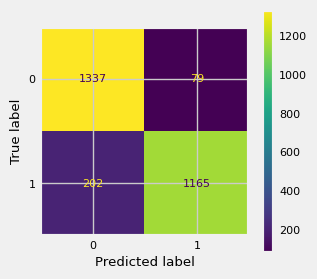

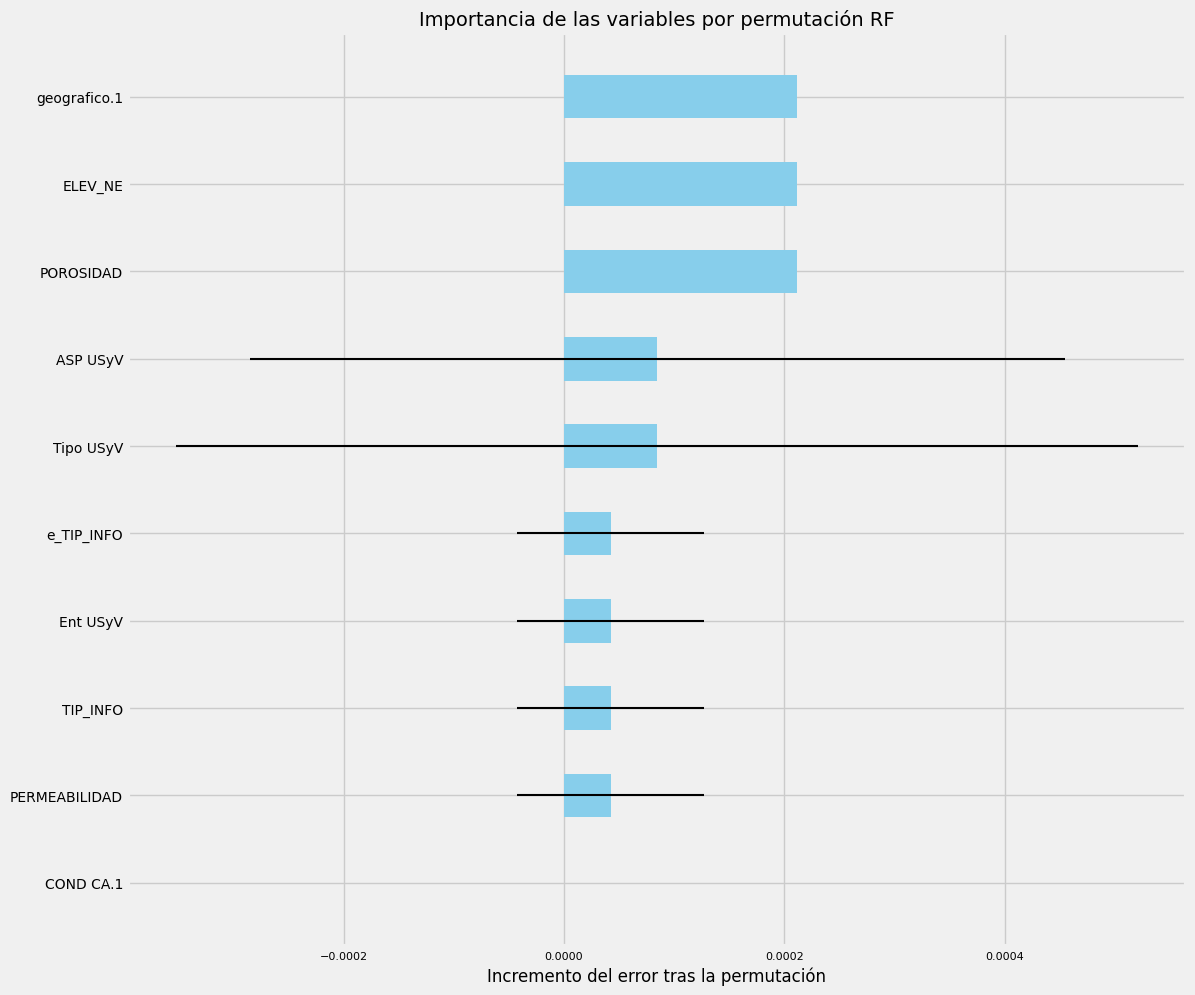

In [ ]:
# Tratamiento de datos
# ==============================================================================
!pip install optuna --quiet
import numpy as np
import pandas as pd
import statsmodels.api as sm
import pickle

# Gráficos
# ==============================================================================
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['font.size'] = 8

# Preprocesado y modelado
# ==============================================================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import ParameterGrid
from sklearn.inspection import permutation_importance
from joblib import Parallel, delayed
import optuna

# Configuración warnings
# ==============================================================================
import warnings

# Descarga de datos
# ==============================================================================
url = ('/content/drive/MyDrive/csv/Archivos finales/Finales codificados/Archivos sin columnas altamente correlacionadas/COMPLETOVM_sincolumnas_altamentecorrelacionadas.csv'
)

# columnas a excluir del análisis (por índice)
idx_excluir = [0,1]

datos = pd.read_csv(url, sep=',')

# Store original X and Y for final output
# Using .copy() to avoid SettingWithCopyWarning later
columnas_originales = datos.iloc[:, idx_excluir].copy()
columnas_originales.columns = ['X_original', 'Y_original'] # Rename for clarity

display(datos.head())
display(datos.info())

# --- Diagnóstico de la columna 'Zonrecdesc' antes de la transformación ---
print("\n--- Análisis de la columna 'Zonrecdesc' antes de la transformación ---")
print(datos['Zonrecdesc'].value_counts())
print("----------------------------------------------------------------------\n")

# Usar np.isclose para comparación de floats para la creación de 'recarga'
datos['recarga'] = np.where(np.isclose(datos['Zonrecdesc'], -0.771575), 1, 0)
# Diagnóstico adicional para la columna 'recarga' después de la transformación
print("--- Análisis de la columna 'recarga' después de la transformación ---")
print(datos['recarga'].value_counts())
print("----------------------------------------------------------------------\n")

# Una vez creada la nueva variable respuesta se descarta la original
datos = datos.drop(columns = 'Zonrecdesc')

# Exclude columns 0 and 1 (X and Y) for model training
# The 'X' and 'Y' columns are at index 0 and 1 after read_csv, so drop by name or index
# Assuming they are named 'X' and 'Y' as per the .info() output
datos_modelo = datos.drop(columns=datos.columns[idx_excluir])


# División de los datos en entrenamiento y test
# ==============================================================================
X_train, X_test, y_train, y_test = train_test_split(
                                        datos_modelo.drop(columns="recarga"), # Use datos_modelo here
                                        datos_modelo['recarga'],             # Use datos_modelo here
                                        test_size = 0.25,
                                        #random_state = 123,
                                        stratify=datos_modelo['recarga']     # Use datos_modelo here
                                    )

print(f"Tamaño conjunto entrenamiento: {X_train.shape[0]}")
print(f"Tamaño conjunto test: {X_test.shape[0]}")

print(f"Balance de clases entrenamiento: {y_train.value_counts()}")
print(f"Balance de clases test: {y_test.value_counts()}")

# Grid de hiperparámetros evaluados
# ==============================================================================
param_grid = ParameterGrid(
                {'n_estimators': [100,300,500],
                 'max_features': [13,16,20,'sqrt'],
                 'max_depth'   : [None, 10, 20,30],
                 'criterion'   : ['gini', 'entropy']
                }
            )

# Loop para ajustar un modelo con cada combinación de hiperparámetros
# ==============================================================================
resultados = {'params': [], 'oob_accuracy': []}

for params in param_grid:

    modelo = RandomForestClassifier(
                oob_score    = True,
                n_jobs        = -1,
                #random_state = 123,
                ** params
             )

    modelo.fit(X_train, y_train)

    resultados['params'].append(params)
    resultados['oob_accuracy'].append(modelo.oob_score_)
    print(f"Modelo: {params} \u2713")

# Resultados
# ==============================================================================
resultados = pd.DataFrame(resultados)
resultados = pd.concat([resultados, resultados['params'].apply(pd.Series)], axis=1)
resultados = resultados.sort_values('oob_accuracy', ascending=False)
resultados = resultados.drop(columns='params')
resultados.head()

# Mejores hiperparámetros por out-of-bag error
# ==============================================================================
print("--------------------------------------------------")
print("Mejores hiperparámetros encontrados (oob-accuracy)")
print("--------------------------------------------------")
print(resultados.iloc[0,0:])


# Extraer mejores hiperparámetros
# ==============================================================================
mejores_params = resultados.iloc[0]

# Handle max_depth being NaN (from original None) in case it was the best param
max_depth_val = int(mejores_params['max_depth']) if pd.notna(mejores_params['max_depth']) else None

# Modelo con los mejores hiperparámetros
# ==============================================================================
modelo_final = RandomForestClassifier(
    n_estimators=int(mejores_params['n_estimators']),
    max_features=mejores_params['max_features'],
    max_depth=max_depth_val,
    criterion=mejores_params['criterion'],
    oob_score=True,
    n_jobs=-1,
    #random_state=123
)

# Entrenamiento del modelo final
# ==============================================================================
modelo_final.fit(X_train, y_train)

#Guardar el modelo final (Cod Manu)
#===============================================================================
#Para guardar el modelo
with open("Modelo_RF.p","wb") as outfile:
  pickle.dump(modelo_final,outfile)

#Para cargar el modelo/abrir
#with open("Modelo_RF.p","rb") as infile:
  #modelo_final= pickle.load(infile)


# Error de test del modelo final
# ==============================================================================
predicciones = modelo_final.predict(X=X_test)
predicciones

# Matriz de confusión
# ==============================================================================
mat_confusion = confusion_matrix(y_true=y_test, y_pred=predicciones, labels=[0, 1]) # Added labels
accuracy = accuracy_score(y_true=y_test, y_pred=predicciones, normalize=True)
print("Matriz de confusión")
print("-------------------")
print(mat_confusion)
print("")
print(f"El accuracy de test es: {100 * accuracy} % \n")
fig, ax = plt.subplots(figsize=(3, 3))
ConfusionMatrixDisplay(mat_confusion).plot(ax=ax)

print(
    classification_report(
        y_true = y_test,
        y_pred = predicciones
    )
)

# Predicción de probabilidades
# ==============================================================================
predicciones = modelo_final.predict_proba(X=X_test) # This 'predicciones' now holds probabilities

# Clasificación empleando la clase de mayor probabilidad
# ==============================================================================

if predicciones.shape[1] == 1:
    # If only one class (0) was observed during training, the single column
    # returned by predict_proba represents P(class=0).
    prob_class_0 = predicciones[:, 0]
    prob_class_1 = 1 - prob_class_0 # In a binary context, P(class=1) = 1 - P(class=0)

    # Create the DataFrame, placing P(class=1) in column '1' and P(class=0) in column '0'.
    df_predicciones = pd.DataFrame(
        data=
        {
            '1': prob_class_1,
            '0': prob_class_0
        },
        columns=['1', '0'] # Explicitly setting the desired column order
    )
elif predicciones.shape[1] == 2:
    # This block handles the standard case where predict_proba returns two columns:
    # [P(class=0), P(class=1)].
    # We need to assign them to columns '1' and '0' as requested by the user,
    # meaning column '1' gets P(class=1) and column '0' gets P(class=0).
    df_predicciones = pd.DataFrame(
        data=
        {
            '1': predicciones[:, 1], # P(class=1) is usually the second column
            '0': predicciones[:, 0]  # P(class=0) is usually the first column
        },
        columns=['1', '0'] # Explicitly setting the desired column order
    )

# If somehow predicciones has more than 2 columns (e.g. multiclass), this needs further handling.
# For now, let's assume it's either 1 or 2 columns based on binary classification context.

df_predicciones['clasificacion_default_0.5'] = np.where(df_predicciones['1'] > df_predicciones['0'], 1, 0)
df_predicciones

# Combine original columns with predictions for final CSV
resultados_finales = pd.concat([
    columnas_originales.reset_index(drop=True),
    df_predicciones['clasificacion_default_0.5'].rename('resultado_recarga').reset_index(drop=True)
], axis=1)

# Map 0/1 to 'No recarga'/'Recarga' as requested
resultados_finales['resultado_recarga'] = resultados_finales['resultado_recarga'].map({0: 'No recarga', 1: 'Recarga'})

# Save to CSV
ruta_salida = "/content/drive/MyDrive/csv/Archivos finales/Finales codificados/Archivos sin columnas altamente correlacionadas/resultados_random_forest_recarga_descarga.csv"
resultados_finales.to_csv(ruta_salida, index=False, encoding="utf-8-sig")
print(f"Resultados guardados en: {ruta_salida}")

#Importancia de los predictores
#===============================================================================

importancia_predictores = pd.DataFrame(
                            {'predictor': X_train.columns,
                             'importancia': modelo_final.feature_importances_}
                            )
print("Importancia de los predictores en el modelo")
print("-------------------------------------------")
print(importancia_predictores.sort_values('importancia', ascending=False))

#Permutación
# You need to import cpu_count from multiprocessing or define it,
# but for simplicity and to avoid potential issues in Colab,
# I'll replace cpu_count() - 1 with a fixed number or just use n_jobs=-1
from os import cpu_count # Import cpu_count
importanza = permutation_importance(
                estimator    = modelo_final,
                X             = X_train,
                y            = y_train,
                n_repeats    = 5,
                scoring      = 'neg_root_mean_squared_error',
                n_jobs       = cpu_count() - 1, # Using cpu_count
                #random_state = 123,
             )

# Se almacenan los resultados (media y desviación) en un dataframe
df_importancia = pd.DataFrame(
                    {k: importanza[k] for k in ['importances_mean', 'importances_std']}
                 )
df_importancia['feature'] = X_train.columns
print(df_importancia.sort_values('importances_mean', ascending=False))

# Gráfico
# ==============================================================================
fig, ax = plt.subplots(figsize=(12, 10)) # Increased figure size
df_importancia = df_importancia.head(10).sort_values('importances_mean', ascending=True)
ax.barh(
    df_importancia['feature'],
    df_importancia['importances_mean'],
    xerr=df_importancia['importances_std'],
    height=0.5, # Made bars smaller
    color='skyblue'
)
#ax.plot(
 #   df_importancia['importances_mean'],
  #  df_importancia['feature'],
   # marker="D",
    #linestyle="",
    #alpha=0.8,
    #color="r"
#)
ax.set_title('Importancia de las variables por permutación RF',fontsize=14)
ax.set_xlabel('Incremento del error tras la permutación',fontsize=12)
ax.tick_params(axis='y', labelsize=10); # Increased y-axis label font size
plt.tight_layout() # Added to ensure the plot is displayed

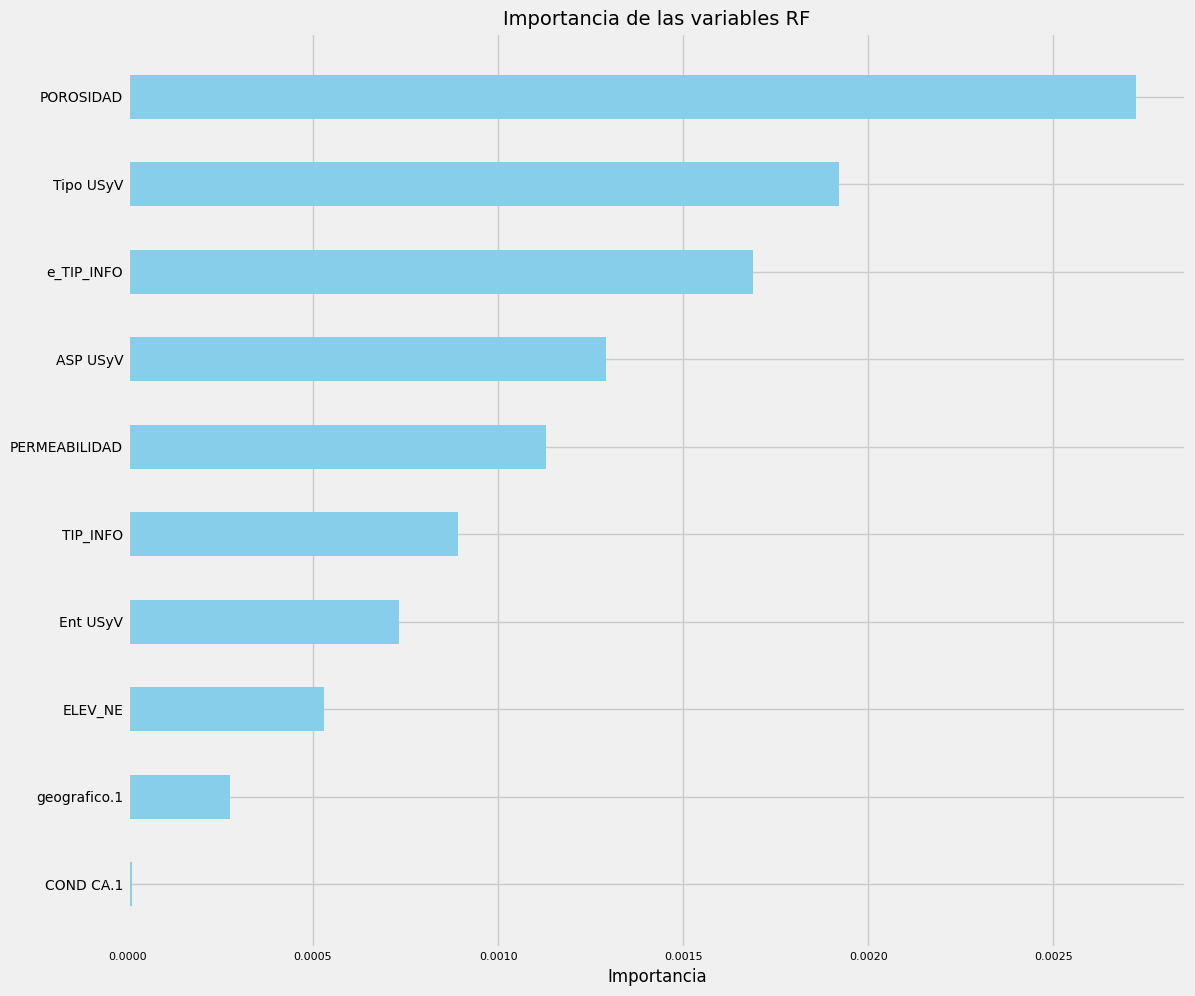

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Gráfico de importancia de los predictores (feature_importances_)
fig, ax = plt.subplots(figsize=(12, 10))
importancia_predictores_sorted = importancia_predictores.head(10).sort_values('importancia', ascending=True)
ax.barh(
    importancia_predictores_sorted['predictor'],
    importancia_predictores_sorted['importancia'],
    height=0.5, # Made bars smaller
    color='skyblue'
)
ax.set_title('Importancia de las variables RF',fontsize=14)
ax.set_xlabel('Importancia',fontsize=12)
ax.tick_params(axis='y', labelsize=10)
plt.tight_layout()
plt.show()

In [ ]:
mat_confusion = confusion_matrix(
    y_true=y_test,
    y_pred=predicciones,
    labels=[0, 1] # Specify all possible labels
)

# **Random forest + Fuzzy logic**

Primeras filas


,X,Y,POROSIDAD,PERMEABILIDAD,Ent USyV,Tipo USyV,ELEV_NE,geografico.1,COND CA.1,TIP_INFO,...,TIP_PLAN.1,NOMA_AGR,EROSION,TIP_ECOV.1.1,TIP_VEG.1,FASE_VS.1,TIP_VEG.3,FASE_VS_US,Densveg,Zonrecdesc
0,456648.6132,2154183.671,2,2,1.469259,-1.321893,0.0,0,0,-0.124367,...,0.084834,0.525102,1,0.468374,0.000179,0.452787,-0.804547,-0.252108,1,-0.771575
1,456978.6132,2154513.671,2,2,1.469259,-1.321893,0.0,0,0,-0.124367,...,0.084834,0.525102,1,0.468374,0.000179,0.452787,-0.804547,-0.252108,1,-0.771575
2,457308.6132,2154183.671,2,2,1.469259,-1.321893,0.0,0,0,-0.124367,...,0.084834,0.525102,1,0.468374,0.000179,0.452787,-0.804547,-0.252108,1,-0.771575
3,457308.6132,2156163.671,2,2,-1.080408,-0.097796,0.0,0,0,0.005778,...,0.084834,0.525102,1,0.003643,0.509224,-0.490988,0.538606,-0.459238,1,-0.771575
4,457638.6132,2154513.671,2,2,1.469259,-1.321893,0.0,0,0,0.005778,...,0.084834,0.525102,1,0.468374,0.000179,0.452787,-0.804547,-0.252108,1,-0.771575



Información del dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11131 entries, 0 to 11130
Data columns (total 82 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   X              11131 non-null  float64
 1   Y              11131 non-null  float64
 2   POROSIDAD      11131 non-null  int64  
 3   PERMEABILIDAD  11131 non-null  int64  
 4   Ent USyV       11131 non-null  float64
 5   Tipo USyV      11131 non-null  float64
 6   ELEV_NE        11131 non-null  float64
 7   geografico.1   11131 non-null  int64  
 8   COND CA.1      11131 non-null  int64  
 9   TIP_INFO       11131 non-null  float64
 10  ASP USyV       11131 non-null  float64
 11  e_TIP_INFO     11131 non-null  float64
 12  e_TIP_ECOV     11131 non-null  float64
 13  DESVEG         11131 non-null  float64
 14  TIP_INFO.1     11131 non-null  float64
 15  TIP_PLAN       11131 non-null  float64
 16  TIP_INFO.2     11131 non-null  float64
 17  DESVEG.1       11131 non-

None


Distribución original Zonrecdesc
Zonrecdesc
-0.771575    5469
-0.623766    3651
 0.000000    1183
 0.728472     828
Name: count, dtype: int64

Distribución variable recarga
recarga
0    5662
1    5469
Name: count, dtype: int64


/tmp/ipykernel_16920/685959116.py:161: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  fuzzy_df[f'{col}_medio'] = medio_f
/tmp/ipykernel_16920/685959116.py:162: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  fuzzy_df[f'{col}_alto'] = alto
/tmp/ipykernel_16920/685959116.py:160: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newfram


Variables difusas generadas
(11131, 237)

Tamaño conjuntos
RF train: (8348, 79)
RF test: (2783, 79)
Fuzzy train: (8348, 237)
Fuzzy test: (2783, 237)
Modelo entrenado: {'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 100}
Modelo entrenado: {'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 300}
Modelo entrenado: {'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 500}
Modelo entrenado: {'criterion': 'gini', 'max_depth': 10, 'max_features': 8, 'n_estimators': 100}
Modelo entrenado: {'criterion': 'gini', 'max_depth': 10, 'max_features': 8, 'n_estimators': 300}
Modelo entrenado: {'criterion': 'gini', 'max_depth': 10, 'max_features': 8, 'n_estimators': 500}
Modelo entrenado: {'criterion': 'gini', 'max_depth': 10, 'max_features': 12, 'n_estimators': 100}
Modelo entrenado: {'criterion': 'gini', 'max_depth': 10, 'max_features': 12, 'n_estimators': 300}
Modelo entrenado: {'criterion': 'gini', 'max_depth': 10, 

,oob_accuracy,criterion,max_depth,max_features,n_estimators
12,0.901294,gini,20.0,sqrt,100
94,0.901294,entropy,NaN,16,300
25,0.901174,gini,30.0,sqrt,300
26,0.901174,gini,30.0,sqrt,500
14,0.901054,gini,20.0,sqrt,500



MATRIZ DE CONFUSIÓN
[[1351   65]
 [ 198 1169]]
El accuracy de test es: 90.5497664390945 % 



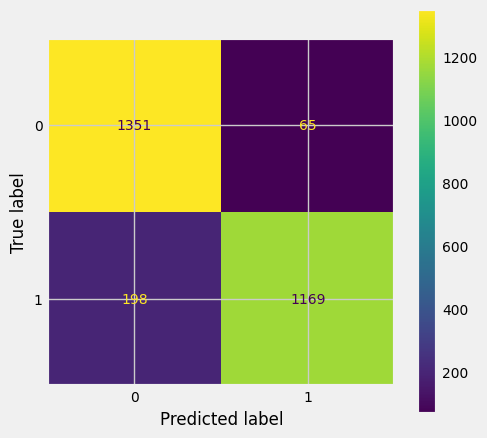


REPORTE DE CLASIFICACIÓN
              precision    recall  f1-score   support

           0       0.87      0.95      0.91      1416
           1       0.95      0.86      0.90      1367

    accuracy                           0.91      2783
   macro avg       0.91      0.90      0.91      2783
weighted avg       0.91      0.91      0.91      2783


Top 10 variables importantes


,predictor,importancia
64,DESCRIP CM,0.233009
22,EntidadUSy,0.154938
21,Pendiente,0.081471
52,DESCRIPCIO.3,0.070142
23,TIPO USyV,0.065168
72,EROSION,0.057860
68,TIP_INFO.4,0.044076
65,TIP_INFO.5,0.041913
74,TIP_VEG.1,0.033564
71,NOMA_AGR,0.032549


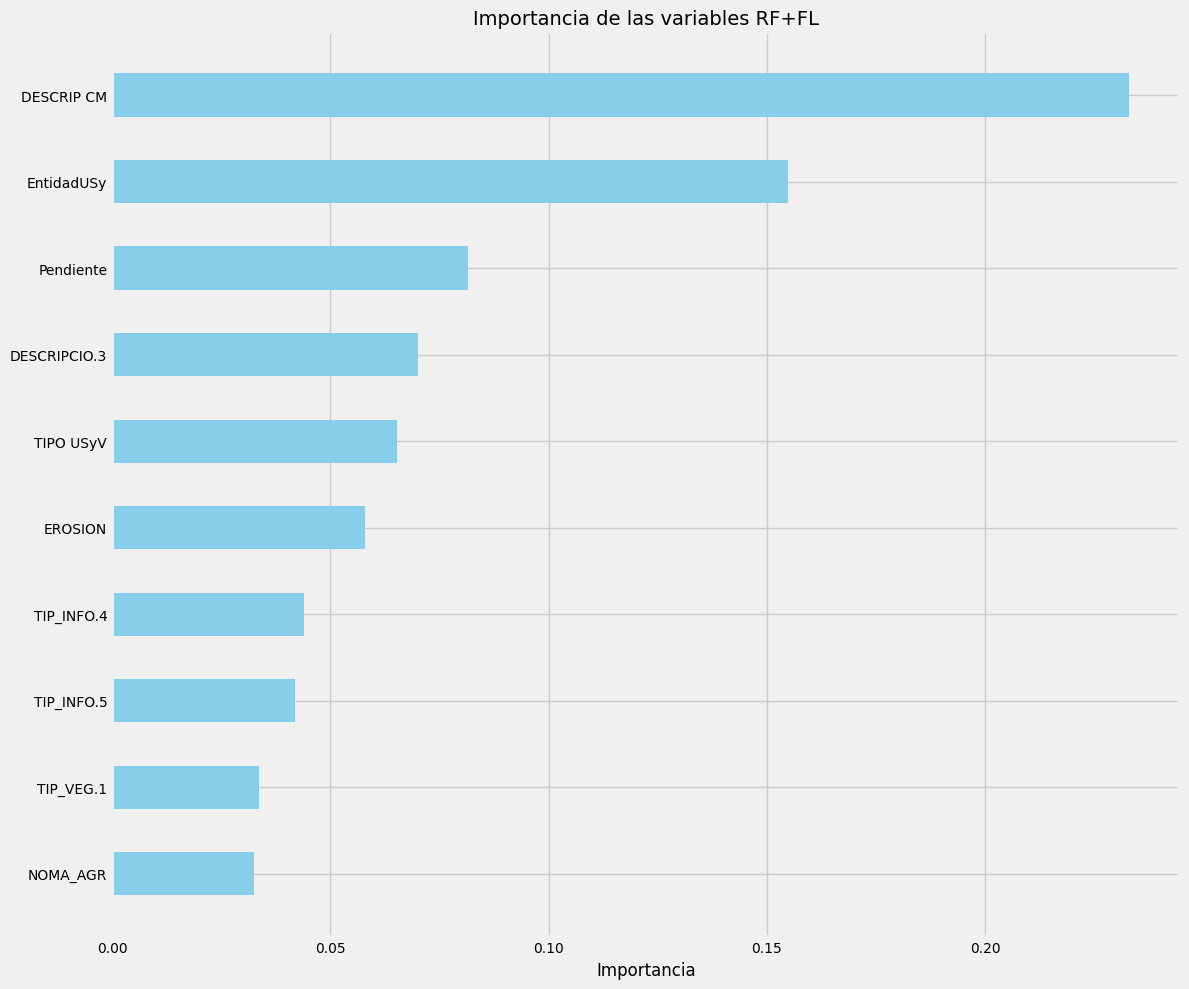


Top 10 importancia permutación


,feature,importances_mean,importances_std
64,DESCRIP CM,0.186632,0.002540
21,Pendiente,0.033373,0.001425
22,EntidadUSy,0.027432,0.001589
23,TIPO USyV,0.023215,0.001208
68,TIP_INFO.4,0.016004,0.001647
72,EROSION,0.015932,0.001772
73,TIP_ECOV.1.1,0.014734,0.000746
65,TIP_INFO.5,0.012961,0.002139
77,FASE_VS_US,0.009990,0.001296
74,TIP_VEG.1,0.007451,0.000917


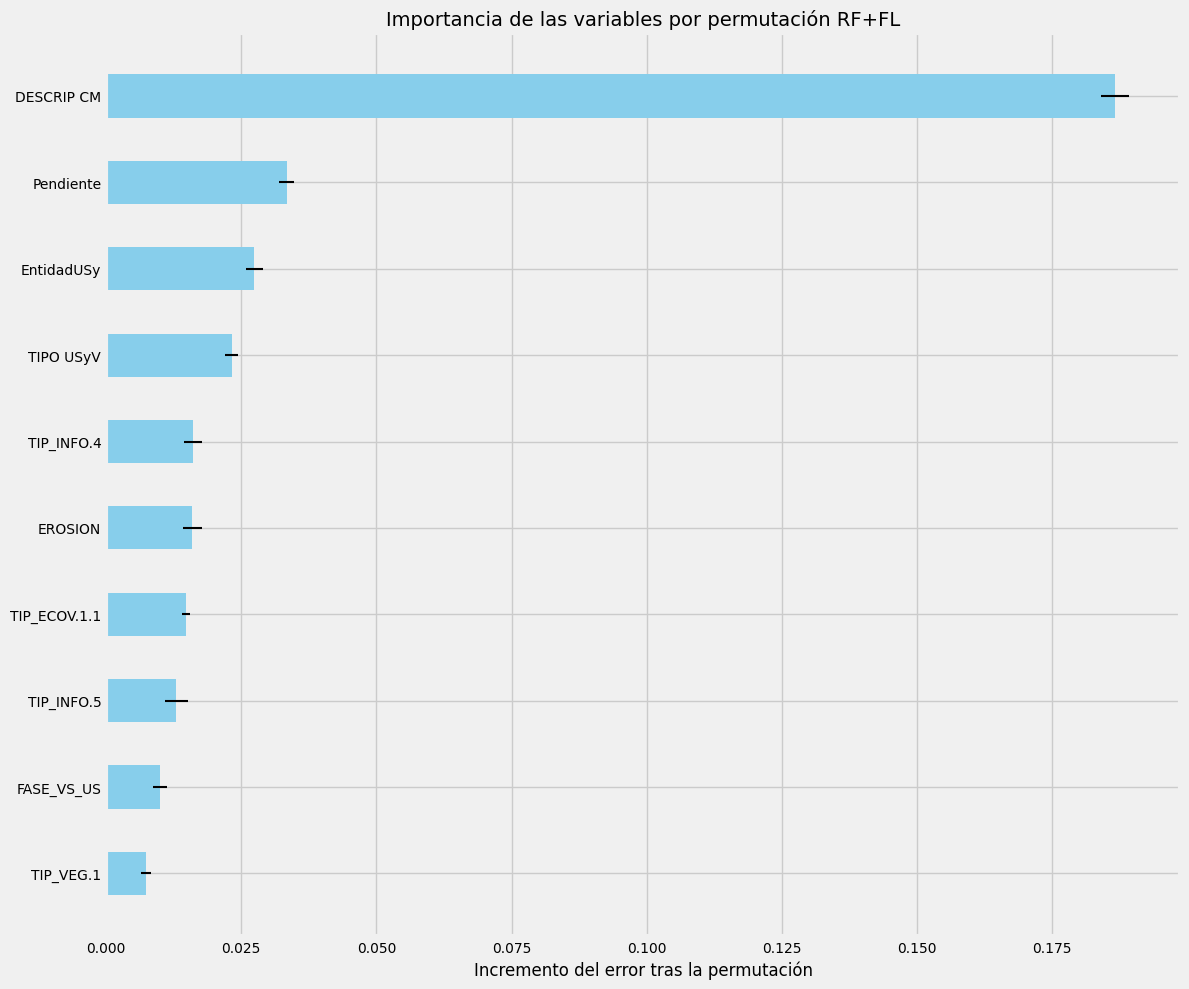


CSV EXPORTADO
/content/drive/MyDrive/csv/Archivos finales/Finales codificados/Archivos sin columnas altamente correlacionadas/resultados_random_forest_FL_recarga_no recarga.csv


In [ ]:
# ==============================================================================
# RANDOM FOREST + FUZZY LOGIC HÍBRIDO
# Clasificación de zonas de recarga y no recarga
# ==============================================================================
# 1 = Recarga
# 0 = No recarga
#
# El código:
#   - Lee archivo CSV
#   - Excluye columnas 0 y 1
#   - Genera variables difusas
#   - Optimiza hiperparámetros RF
#   - Construye modelo híbrido RF + FL
#   - Evalúa resultados
#   - Genera gráficas
#   - Calcula importancia de variables
#   - Exporta CSV fina
# ==============================================================================


# ==============================================================================
# LIBRERÍAS
# ==============================================================================

!pip install scikit-fuzzy --quiet

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import train_test_split
from sklearn.model_selection import ParameterGrid

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

from sklearn.inspection import permutation_importance

import skfuzzy as fuzz
import pickle


# ==============================================================================
# CONFIGURACIÓN DE GRÁFICOS
# ==============================================================================

plt.style.use('fivethirtyeight')

plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['font.size'] = 10


# ==============================================================================
# RUTA DEL ARCHIVO
# ==============================================================================

url = ('/content/drive/MyDrive/csv/Archivos finales/Finales codificados/Archivos sin columnas altamente correlacionadas/COMPLETOVM_sincolumnas_altamentecorrelacionadas.csv')


# ==============================================================================
# CARGA DE DATOS
# ==============================================================================

datos = pd.read_csv(url)

print("Primeras filas")
display(datos.head())

print("\nInformación del dataset")
display(datos.info())


# ==============================================================================
# GUARDAR COLUMNAS 0 Y 1
# ==============================================================================
# Se usarán solamente para exportar resultados
# ==============================================================================

idx_excluir = [0,1]

columnas_originales = datos.iloc[:, idx_excluir].copy()

columnas_originales.columns = ['X_original','Y_original']


# ==============================================================================
# TRANSFORMACIÓN VARIABLE OBJETIVO
# ==============================================================================

print("\nDistribución original Zonrecdesc")
print(datos['Zonrecdesc'].value_counts())

datos['recarga'] = np.where(
    np.isclose(datos['Zonrecdesc'], -0.771575), 1, 0)

print("\nDistribución variable recarga")
print(datos['recarga'].value_counts())


# ==============================================================================
# ELIMINAR Coordenadas
# ==============================================================================

datos = datos.drop(columns='Zonrecdesc')

datos_modelo = datos.drop(columns=datos.columns[idx_excluir])


# ==============================================================================
# VARIABLES PREDICTORAS Y OBJETIVO
# ==============================================================================

X = datos_modelo.drop(columns='recarga')

y = datos_modelo['recarga']


# ==============================================================================
# FUNCIÓN PARA GENERAR VARIABLES DIFUSAS
# ==============================================================================
# Convierte cada variable en memberships:
#
#   bajo
#   medio
#   alto
#
# usando funciones triangulares
# ==============================================================================

def make_fuzzy_features(df):

    fuzzy_df = pd.DataFrame(index=df.index)

    for col in df.columns:

        x = df[col].values

        minimo = np.min(x)
        maximo = np.max(x)
        medio = np.median(x)

        # Bajo
        bajo = fuzz.trimf(x,[minimo, minimo, medio])

        # Medio
        medio_f = fuzz.trimf(x,[minimo, medio, maximo])

        # Alto
        alto = fuzz.trimf(x,[medio, maximo, maximo])

        fuzzy_df[f'{col}_bajo'] = bajo
        fuzzy_df[f'{col}_medio'] = medio_f
        fuzzy_df[f'{col}_alto'] = alto

    return fuzzy_df


# ==============================================================================
# CREAR VARIABLES DIFUSAS
# ==============================================================================

X_fuzzy = make_fuzzy_features(X)

print("\nVariables difusas generadas")
print(X_fuzzy.shape)


# ==============================================================================
# DIVISIÓN TRAIN TEST
# ==============================================================================

Xr_train, Xr_test, Xf_train, Xf_test, y_train, y_test = train_test_split(
    X,X_fuzzy,y,test_size=0.25,stratify=y,
    #random_state=42
)

print("\n===================================")
print("Tamaño conjuntos")
print("===================================")

print(f"RF train: {Xr_train.shape}")
print(f"RF test: {Xr_test.shape}")

print(f"Fuzzy train: {Xf_train.shape}")
print(f"Fuzzy test: {Xf_test.shape}")


# ==============================================================================
# GRID DE HIPERPARÁMETROS
# ==============================================================================

param_grid = ParameterGrid(
    {
        'n_estimators': [100, 300, 500],
        'max_features': ['sqrt',8,12,16],
        'max_depth': [10,20,30,None],
        'criterion': ['gini','entropy'] })


# ==============================================================================
# BÚSQUEDA DE MEJORES HIPERPARÁMETROS
# ==============================================================================

resultados = {
    'params': [],
    'oob_accuracy': []}

for params in param_grid:

    modelo = RandomForestClassifier(
        oob_score=True,n_jobs=-1,
        #random_state=42,
        **params)

    modelo.fit(Xr_train, y_train)

    resultados['params'].append(params)

    resultados['oob_accuracy'].append(
        modelo.oob_score_)

    print(f"Modelo entrenado: {params}")


# ==============================================================================
# RESULTADOS HIPERPARÁMETROS
# ==============================================================================

resultados = pd.DataFrame(resultados)

resultados = pd.concat(
    [resultados, resultados['params'].apply(pd.Series)],
    axis=1)

resultados = resultados.sort_values('oob_accuracy',ascending=False)

resultados = resultados.drop(columns='params')

print("\nMejores hiperparámetros")
display(resultados.head())


# ==============================================================================
# EXTRAER MEJORES PARÁMETROS
# ==============================================================================

mejores_params = resultados.iloc[0]

max_depth_val = (
    int(mejores_params['max_depth'])
    if pd.notna(mejores_params['max_depth'])
    else None)


# ==============================================================================
# RANDOM FOREST FINAL
# ==============================================================================

rf = RandomForestClassifier(
    n_estimators=int(mejores_params['n_estimators']),
    max_features=mejores_params['max_features'],
    max_depth=max_depth_val,
    criterion=mejores_params['criterion'],
    oob_score=True,
    n_jobs=-1)
    #random_state=42

rf.fit(Xr_train, y_train)


# ==============================================================================
# PROBABILIDADES RANDOM FOREST
# ==============================================================================

p_rf = rf.predict_proba(Xr_test)


# ==============================================================================
# CENTROIDES DIFUSOS
# ==============================================================================
# Parte FUZZY LOGIC
# ==============================================================================

classes = np.unique(y_train)

centroids = {}

for c in classes:

    centroids[c] = (Xf_train[y_train == c].mean(axis=0).values)


# ==============================================================================
# FUNCIÓN PROBABILIDADES DIFUSAS
# ==============================================================================
# Convierte memberships difusos en probabilidades
# usando similitud (coseno o dot)
# ==============================================================================

def fuzzy_probs(Xf, centroids):

    Xtemp = Xf.values

    class_list = sorted(centroids.keys())

    sims = np.vstack([(Xtemp @ centroids[c])for c in class_list]).T #dimilitud del producto dot

    sims = np.maximum(0, sims)

    row_sums = (sims.sum(axis=1, keepdims=True)+ 1e-9)

    return sims / row_sums, class_list #devuelve prob-like y orden de clases


# ==============================================================================
# PROBABILIDADES DIFUSAS
# ==============================================================================

p_fuzzy, class_order = fuzzy_probs(Xf_test,centroids)

# ==============================================================================
# ALINEAR CLASES RF Y FUZZY
# Alinear columnas de p_rf con class_order si hace falta
# asumo rf.classes_ coincide con class_order; si no, reordenar p_rf en dicho orden:
# ==============================================================================

order_map = [list(rf.classes_).index(c)for c in class_order]

p_rf_reordered = p_rf[:, order_map]

# ==============================================================================
# ENSAMBLE PONDERADO HÍBRIDO RF + FUZZY
# ==============================================================================
# alpha:peso RF
#
# 1-alpha:peso fuzzy
# ==============================================================================

alpha = 0.6

p_ensemble = (alpha * p_rf_reordered + (1 - alpha) * p_fuzzy)

# ==============================================================================
# CLASIFICACIÓN FINAL
# ==============================================================================

y_ensemble = np.array(class_order)[p_ensemble.argmax(axis=1)]

#===============================================================================
#Guardar el modelo final (Cod Manu)
#===============================================================================
#Para guardar el modelo
with open("Modelo_RF1_FL_PRF.p","wb") as outfile:
  pickle.dump(rf,outfile)

#Para guardar el modelo
with open("Modelo_RF2_FL_PFL.p","wb") as outfile:
  pickle.dump(centroids,outfile)

 #Para guardar el modelo
with open("Modelo_RF3_FL.p","wb") as outfile:
  pickle.dump(X_fuzzy,outfile)

#Para cargar el modelo/abrir
#with open("Modelo_RF_FL.p","rb") as infile:
  #modelo_final= pickle.load(infile)


# ==============================================================================
# MATRIZ DE CONFUSIÓN
# ==============================================================================

mat_confusion = confusion_matrix(y_test,y_ensemble)

accuracy = accuracy_score(y_test,y_ensemble)

print("\n===================================")
print("MATRIZ DE CONFUSIÓN")
print("===================================")

print(mat_confusion)

print(f"El accuracy de test es: {100 * accuracy} % \n")

fig, ax = plt.subplots(figsize=(5,5))

ConfusionMatrixDisplay(mat_confusion).plot(ax=ax)
plt.show()


# ==============================================================================
# REPORTE DE CLASIFICACIÓN
# ==============================================================================
# precision
# recall
# f1-score
# support
# ==============================================================================

print("\n===================================")
print("REPORTE DE CLASIFICACIÓN")
print("===================================")

print(classification_report(y_test,y_ensemble))

# ==============================================================================
# IMPORTANCIA VARIABLES RF
# ==============================================================================

importancia_predictores = pd.DataFrame({'predictor': Xr_train.columns,
'importancia': rf.feature_importances_})

importancia_predictores = (importancia_predictores.sort_values('importancia',
        ascending=False))

print("\nTop 10 variables importantes")

display(
    importancia_predictores.head(10))


# ==============================================================================
# GRÁFICA IMPORTANCIA VARIABLES
# ==============================================================================

fig, ax = plt.subplots(figsize=(12,10))

top_vars = (importancia_predictores.head(10).sort_values('importancia',
        ascending=True))

ax.barh(top_vars['predictor'],top_vars['importancia'],height=0.5, color='skyblue')

ax.set_title('Importancia de las variables RF+FL',fontsize=14)
ax.set_xlabel('Importancia',fontsize=12)
ax.tick_params(axis='y', labelsize=10)
plt.tight_layout()

plt.show()

# ==============================================================================
# IMPORTANCIA POR PERMUTACIÓN
# ==============================================================================

importancia_perm = permutation_importance(
    estimator=rf,
    X=Xr_train,
    y=y_train,
    n_repeats=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42)

# ==============================================================================
# DATAFRAME IMPORTANCIA PERMUTACIÓN
# ==============================================================================

df_perm = pd.DataFrame({'feature': Xr_train.columns,'importances_mean':importancia_perm.importances_mean,
'importances_std':importancia_perm.importances_std})

df_perm = df_perm.sort_values('importances_mean',ascending=False)

print("\nTop 10 importancia permutación")

display(df_perm.head(10))

# ==============================================================================
# GRÁFICA IMPORTANCIA PERMUTACIÓN
# ==============================================================================

fig, ax = plt.subplots(figsize=(12,10))

top_perm = (df_perm.head(10).sort_values('importances_mean',ascending=True))

ax.barh(
    top_perm['feature'],
    top_perm['importances_mean'],
    xerr=top_perm['importances_std'], # Added error bars
    color='skyblue',
    height=0.5
)

ax.set_title('Importancia de las variables por permutación RF+FL',fontsize=14)
ax.set_xlabel('Incremento del error tras la permutación',fontsize=12)
ax.tick_params(axis='y', labelsize=10)
plt.tight_layout()

plt.show()

# ==============================================================================
# Gráfico de importancia de los predictores (feature_importances_)
# ==============================================================================
#fig, ax = plt.subplots(figsize=(12, 10))
#importancia_predictores_sorted = importancia_predictores.head(10).sort_values('importancia', ascending=True)
#ax.barh(
 #   importancia_predictores_sorted['predictor'],
  #  importancia_predictores_sorted['importancia'],
   # color='skyblue'
#)
#ax.set_title('Importancia de los predictores')
#ax.set_xlabel('Importancia')
#ax.tick_params(axis='y', labelsize=6)
#plt.tight_layout()
#plt.show()

# ==============================================================================
# PREDICCIÓN SOBRE TODO EL DATASET
# ==============================================================================

p_rf_all = rf.predict_proba(X)

p_fuzzy_all, _ = fuzzy_probs(X_fuzzy,centroids)

p_rf_all = p_rf_all[:, order_map]

p_ensemble_all = (alpha * p_rf_all +(1 - alpha) * p_fuzzy_all)

y_all = np.array(class_order)[p_ensemble_all.argmax(axis=1)]

# ==============================================================================
# CREAR CSV FINAL
# ==============================================================================

resultados_finales = pd.concat([columnas_originales.reset_index(drop=True),
pd.Series(y_all,name='resultado_recarga')], axis=1)

# ==============================================================================
# CAMBIAR 0/1 A TEXTO
# ==============================================================================

resultados_finales['resultado_recarga'] = (resultados_finales['resultado_recarga']
    .map({
        0: 'No recarga',
        1: 'Recarga'}))

# ==============================================================================
# EXPORTAR CSV
# ==============================================================================

ruta_salida = ('/content/drive/MyDrive/csv/Archivos finales/Finales codificados/Archivos sin columnas altamente correlacionadas/resultados_random_forest_FL_recarga_no recarga.csv')

resultados_finales.to_csv(ruta_salida,index=False,encoding='utf-8-sig')

print("\n===================================")
print("CSV EXPORTADO")
print("===================================")

print(ruta_salida)

**ROC**

In [ ]:
# ==============================================================================
# ROC - AUC COMPARACIÓN RF vs RF+FL
# ==============================================================================

from sklearn.metrics import (
    roc_curve,
    auc,
    roc_auc_score)

import matplotlib.pyplot as plt

# ==============================================================================
# PROBABILIDADES RF
# ==============================================================================

# RF puro
# Probabilidad de la clase positiva (Recarga=1)

y_score_RF = modelo_final.predict_proba(X_test)[:,1]

# ==============================================================================
# PROBABILIDADES RF + FL
# ==============================================================================

# p_ensemble contiene:
# columna 0 = No Recarga
# columna 1 = Recarga

y_score_RF_FL = p_ensemble[:,1]

# ==============================================================================
# ROC RF
# ==============================================================================

fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test,y_score_RF)

auc_rf = roc_auc_score(y_test,y_score_RF)

# ==============================================================================
# ROC RF + FL
# ==============================================================================

fpr_fl, tpr_fl, thresholds_fl = roc_curve(y_test,y_score_RF_FL)

auc_fl = roc_auc_score(y_test,y_score_RF_FL)

# ==============================================================================
# IMPRIMIR RESULTADOS
# ==============================================================================

print("\n===================================")
print("RESULTADOS ROC-AUC")
print("===================================")

print(f"RF      AUC = {auc_rf:.4f}")
print(f"RF+FL   AUC = {auc_fl:.4f}")

# ==============================================================================
# GRÁFICA
# ==============================================================================

plt.figure(figsize=(8,7))

# RF
plt.plot(fpr_rf,tpr_rf,lw=2,color='green',label=f'RF (AUC = {auc_rf:.3f})')

# RF + FL
plt.plot(fpr_fl,tpr_fl,lw=2,color='red',label=f'RF + FL (AUC = {auc_fl:.3f})')

# Línea aleatoria
plt.plot([0,1],[0,1],'--',color='gray',label='Línea de Referencia (AUC = 0.5)')

plt.xlim([0,1])
plt.ylim([0,1.02])

plt.xlabel('1 - Especificidad',fontsize=12)

plt.ylabel('Sensibilidad',fontsize=12)

plt.title('Comparación de Curvas ROC',fontsize=14,fontweight='bold')

plt.legend(loc='lower right',fontsize=10) # Increased font size

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

ValueError: Found input variables with inconsistent numbers of samples: [2783, 45335]

# **La Sierra**

**RF**

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import pickle

# Gráficos
# ==============================================================================
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['font.size'] = 8

# Preprocesado y modelado
# ==============================================================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import ParameterGrid
from sklearn.inspection import permutation_importance
from joblib import Parallel, delayed
import optuna

# Configuración warnings
# ==============================================================================
import warnings

# Descarga de datos
# ==============================================================================
url = ('/content/drive/MyDrive/La Sierra-20260427T041950Z-3-001/La Sierra/Unidas/Codificadas/Archivos sin columnas altamente correlacionadas/COMPLETOLS_sincolumnas_altamentecorrelacionadas.csv'
)

# columnas a excluir del análisis (por índice)
idx_excluir = [0,1]

datos = pd.read_csv(url, sep=',')

# Store original X and Y for final output
# Using .copy() to avoid SettingWithCopyWarning later
columnas_originales = datos.iloc[:, idx_excluir].copy()
columnas_originales.columns = ['X_original', 'Y_original'] # Rename for clarity

display(datos.head())
display(datos.info())
datos_modelo = datos.drop(columns=datos.columns[idx_excluir])

# ==============================================================================

#Llamar al modelo final (Cod Manu)
#===============================================================================
#Para guardar el modelo
#with open("Modelo_RF.p","wb") as outfile:
 # pickle.dump(modelo_final,outfile)

#Para cargar el modelo/abrir
with open("Modelo_RF.p","rb") as infile:
  modelo_final= pickle.load(infile)


# ==============================================================================
# Fix: Align datos_modelo columns with the features the model was trained on
# ==============================================================================
if hasattr(modelo_final, 'feature_names_in_'):
    # Get the feature names the model was trained with
    expected_features = list(modelo_final.feature_names_in_)

    # Identify missing columns in datos_modelo
    missing_cols = set(expected_features) - set(datos_modelo.columns)
    for c in missing_cols:
        datos_modelo[c] = 0.0 # Add missing columns, fill with 0.0 (or appropriate default)

    # Identify extra columns in datos_modelo
    extra_cols = set(datos_modelo.columns) - set(expected_features)
    datos_modelo = datos_modelo.drop(columns=list(extra_cols))

    # Ensure the order of columns matches the training data
    datos_modelo = datos_modelo[expected_features]
else:
    print("Warning: Model does not have 'feature_names_in_'. Cannot align features automatically.")
    print("Please ensure 'datos_modelo' columns match training data manually.")

# Error de test del modelo final
# ==============================================================================
predicciones = modelo_final.predict(datos_modelo)
predicciones


# Predicción de probabilidades
# ==============================================================================
predicciones = modelo_final.predict_proba(datos_modelo) # This 'predicciones' now holds probabilities

# Clasificación empleando la clase de mayor probabilidad
# ==============================================================================
# The error "ValueError: Shape of passed values is (2783, 1), indices imply (2783, 2)"
# occurs because `predicciones` from `predict_proba` has only 1 column,
# but the `pd.DataFrame` constructor is asked to create 2 columns named ['1', '0'].
# This indicates that the `y_train` dataset used for training the model
# only contained a single class (class 0, as seen in the output for balance de clases).
# A RandomForestClassifier trained on a single-class target will output a
# probability array with only one column.

if predicciones.shape[1] == 1:
    # If only one class (0) was observed during training, the single column
    # returned by predict_proba represents P(class=0).
    prob_class_0 = predicciones[:, 0]
    prob_class_1 = 1 - prob_class_0 # In a binary context, P(class=1) = 1 - P(class=0)

    # Create the DataFrame, placing P(class=1) in column '1' and P(class=0) in column '0'.
    df_predicciones = pd.DataFrame(
        data=
        {
            '1': prob_class_1,
            '0': prob_class_0
        },
        columns=['1', '0'] # Explicitly setting the desired column order
    )
elif predicciones.shape[1] == 2:
    # This block handles the standard case where predict_proba returns two columns:
    # [P(class=0), P(class=1)].
    # We need to assign them to columns '1' and '0' as requested by the user,
    # meaning column '1' gets P(class=1) and column '0' gets P(class=0).
    df_predicciones = pd.DataFrame(
        data=
        {
            '1': predicciones[:, 1], # P(class=1) is usually the second column
            '0': predicciones[:, 0]  # P(class=0) is usually the first column
        },
        columns=['1', '0'] # Explicitly setting the desired column order
    )

# If somehow predicciones has more than 2 columns (e.g. multiclass), this needs further handling.
# For now, let's assume it's either 1 or 2 columns based on binary classification context.

df_predicciones['clasificacion_default_0.5'] = np.where(df_predicciones['1'] > df_predicciones['0'], 1, 0)
df_predicciones

# Combine original columns with predictions for final CSV
resultados_finales = pd.concat([
    columnas_originales.reset_index(drop=True),
    df_predicciones['clasificacion_default_0.5'].rename('resultado_recarga').reset_index(drop=True)
], axis=1)

# Map 0/1 to 'No recarga'/'Recarga' as requested
resultados_finales['resultado_recarga'] = resultados_finales['resultado_recarga'].map({0: 'No recarga', 1: 'Recarga'})

# Save to CSV
ruta_salida = "/content/drive/MyDrive/La Sierra-20260427T041950Z-3-001/La Sierra/Unidas/Codificadas/Archivos sin columnas altamente correlacionadas/resultados_RF_LS_1.csv"
resultados_finales.to_csv(ruta_salida, index=False, encoding="utf-8-sig")
print(f"Resultados guardados en: {ruta_salida}")

/tmp/ipykernel_16920/458535978.py:43: DtypeWarning: Columns (0,1) have mixed types. Specify dtype option on import or set low_memory=False.
  datos = pd.read_csv(url, sep=',')


,utmx,utmy,e_TIP_INFO,Densveg,CA,MG,NA,K,PH,HCO3,...,TIP_INFO.7,TIP_INFO.1.1,TIP_INFO.5,TIP_ECOV.1,TIP_INFO.6,NOMA_AGR,DESCRIPCIO.3,TIP_VEG.3,Ent USyV,DESCRIPCIO.3.1
0,510568.6156,1965112.48,0.734358,-1.288415,0.0,0.0,0.0,0.0,0.0,0.0,...,0.500129,1.105027,-0.929123,-0.155093,0.471458,-0.055760,0.337775,0.122124,0.063925,1.017942
1,510568.6156,1964412.48,0.734358,-1.288415,0.0,0.0,0.0,0.0,0.0,0.0,...,0.500129,1.105027,-0.929123,-0.155093,0.471458,-0.055760,0.337775,0.122124,0.063925,1.017942
2,510568.6156,1963712.48,0.734358,-1.288415,0.0,0.0,0.0,0.0,0.0,0.0,...,0.500129,1.105027,-0.929123,-0.155093,0.471458,-0.055760,0.337775,0.122124,0.063925,1.017942
3,510918.6156,1964062.48,0.734358,-1.288415,0.0,0.0,0.0,0.0,0.0,0.0,...,0.500129,1.105027,-0.929123,-0.155093,0.471458,-0.055760,0.337775,0.122124,0.063925,1.017942
4,510918.6156,1963362.48,0.734358,-1.288415,0.0,0.0,0.0,0.0,0.0,0.0,...,0.500129,0.664932,-0.036354,0.452925,0.144031,0.948012,0.337775,1.156427,0.502584,1.017942


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45335 entries, 0 to 45334
Data columns (total 69 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   utmx            45335 non-null  object 
 1   utmy            45335 non-null  object 
 2   e_TIP_INFO      45335 non-null  float64
 3   Densveg         45335 non-null  float64
 4   CA              45335 non-null  float64
 5   MG              45335 non-null  float64
 6   NA              45335 non-null  float64
 7   K               45335 non-null  float64
 8   PH              45335 non-null  float64
 9   HCO3            45335 non-null  float64
 10  entidad.1       45335 non-null  float64
 11  entidad.2       45335 non-null  float64
 12  Tipo USyV       45335 non-null  float64
 13  FASE_VS_US      45335 non-null  int64  
 14  erosion         45335 non-null  int64  
 15  geografico AC   45335 non-null  float64
 16  geografico.5    45335 non-null  float64
 17  COND CA         45335 non-null 

None

Resultados guardados en: /content/drive/MyDrive/La Sierra-20260427T041950Z-3-001/La Sierra/Unidas/Codificadas/Archivos sin columnas altamente correlacionadas/resultados_RF_LS_1.csv


# **RF+FL**

In [ ]:
 # ==============================================================================
# RANDOM FOREST + FUZZY LOGIC HÍBRIDO
# Clasificación de zonas de recarga y no recarga
# ==============================================================================
# 1 = Recarga
# 0 = No recarga
#
# El código:
#   - Lee archivo CSV
#   - Excluye columnas 0 y 1
#   - Genera variables difusas
#   - Optimiza hiperparámetros RF
#   - Construye modelo híbrido RF + FL
#   - Evalúa resultados
#   - Genera gráficas
#   - Calcula importancia de variables
#   - Exporta CSV final
# ==============================================================================


# ==============================================================================
# LIBRERÍAS
# ==============================================================================

!pip install scikit-fuzzy --quiet

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import train_test_split
from sklearn.model_selection import ParameterGrid

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

from sklearn.inspection import permutation_importance

import skfuzzy as fuzz
import pickle


# ==============================================================================
# CONFIGURACIÓN DE GRÁFICOS
# ==============================================================================

plt.style.use('fivethirtyeight')

plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['font.size'] = 10


# ==============================================================================
# RUTA DEL ARCHIVO
# ==============================================================================

url = ('/content/drive/MyDrive/La Sierra-20260427T041950Z-3-001/La Sierra/Unidas/Codificadas/Archivos sin columnas altamente correlacionadas/COMPLETOLS_sincolumnas_altamentecorrelacionadas.csv')


# ==============================================================================
# CARGA DE DATOS
# ==============================================================================

datos = pd.read_csv(url)

print("Primeras filas")
display(datos.head())

print("\nInformación del dataset")
display(datos.info())


# ==============================================================================
# GUARDAR COLUMNAS 0 Y 1
# ==============================================================================
# Se usarán solamente para exportar resultados
# ==============================================================================

idx_excluir = [0,1]

columnas_originales = datos.iloc[:, idx_excluir].copy()

columnas_originales.columns = ['X_original','Y_original']


# ==============================================================================
# ELIMINAR Coordenadas
# ==============================================================================

#datos = datos.drop(columns='Zonrecdesc')

# 'datos_modelo_raw' will hold the features for prediction BEFORE alignment and fuzzy transformation
datos_modelo_raw = datos.drop(columns=datos.columns[idx_excluir])

#===============================================================================
#Llamar al modelo final (Cod Manu)
#===============================================================================
#Para guardar el modelo
#with open("Modelo_RF_FL.p","wb") as outfile:
 # pickle.dump(y_ensemble,outfile)

#Para cargar el modelo/abrir RF SOLITO
with open("Modelo_RF1_FL_PRF.p","rb") as infile:
  rf= pickle.load(infile)

#Para cargar el modelo/abrir
with open("Modelo_RF2_FL_PFL.p","rb") as infile:
  centroids= pickle.load(infile)

 #Para cargar el modelo/abrir
with open("Modelo_RF3_FL.p","rb") as infile:
  X_fuzzy_training_example= pickle.load(infile)

# ==============================================================================
# ALINEAR FEATURES PARA PREDICCIÓN
# ==============================================================================
# The model 'rf' expects features with specific names and in a specific order.
# 'datos_modelo_raw' (derived from the current CSV) needs to be aligned.

# Get expected feature names from the loaded model
# Assuming rf.feature_names_in_ is available (scikit-learn >= 0.23)
rf_expected_raw_features = rf.feature_names_in_

# Create a DataFrame with all expected features, filled with 0 (or NaN, then impute)
# Using 0 as a placeholder for missing features is a common approach if absence implies no contribution.
raw_data_for_prediction = pd.DataFrame(0.0, index=datos_modelo_raw.index, columns=rf_expected_raw_features)

# Copy common columns from datos_modelo_raw to raw_data_for_prediction
common_features = list(set(datos_modelo_raw.columns) & set(rf_expected_raw_features))
raw_data_for_prediction[common_features] = datos_modelo_raw[common_features]

# Ensure the order of columns matches rf_expected_raw_features
raw_data_for_prediction = raw_data_for_prediction[rf_expected_raw_features]

# ==============================================================================
# FUNCIÓN PARA GENERAR VARIABLES DIFUSAS
# ==============================================================================
# Convierte cada variable en memberships:
#
#   bajo
#   medio
#   alto
#
# usando funciones triangulares
# ==============================================================================

def make_fuzzy_features(df):

    fuzzy_df = pd.DataFrame(index=df.index)

    for col in df.columns:

        x = df[col].values

        minimo = np.min(x)
        maximo = np.max(x)
        medio = np.median(x)

        # Bajo
        bajo = fuzz.trimf(x,[minimo, minimo, medio])

        # Medio
        medio_f = fuzz.trimf(x,[minimo, medio, maximo])

        # Alto
        alto = fuzz.trimf(x,[medio, maximo, maximo])

        fuzzy_df[f'{col}_bajo'] = bajo
        fuzzy_df[f'{col}_medio'] = medio_f
        fuzzy_df[f'{col}_alto'] = alto

    return fuzzy_df

# ==============================================================================
# GENERAR VARIABLES DIFUSAS PARA DATOS DE PREDICCIÓN
# ==============================================================================
# The fuzzy part needs its own fuzzy features from the 'raw_data_for_prediction'

raw_data_fuzzy_for_prediction = make_fuzzy_features(raw_data_for_prediction)


# ==============================================================================
# PROBABILIDADES RANDOM FOREST
# ==============================================================================

p_rf = rf.predict_proba(raw_data_for_prediction)

# ==============================================================================
# FUNCIÓN PROBABILIDADES DIFUSAS
# ==============================================================================
# Convierte memberships difusos en probabilidades
# usando similitud (coseno o dot)
# ==============================================================================

def fuzzy_probs(Xf, centroids):

    Xtemp = Xf.values

    class_list = sorted(centroids.keys())

    sims = np.vstack([(Xtemp @ centroids[c])for c in class_list]).T #dimilitud del producto dot

    sims = np.maximum(0, sims)

    row_sums = (sims.sum(axis=1, keepdims=True)+ 1e-9)

    return sims / row_sums, class_list #devuelve prob-like y orden de clases


# ==============================================================================
# PROBABILIDADES DIFUSAS
# ==============================================================================

p_fuzzy, class_order = fuzzy_probs(raw_data_fuzzy_for_prediction,centroids)

# ==============================================================================
# ALINEAR CLASES RF Y FUZZY
# Alinear columnas de p_rf con class_order si hace falta
# asumo rf.classes_ coincide con class_order; si no, reordenar p_rf en dicho orden:
# ==============================================================================

order_map = [list(rf.classes_).index(c)for c in class_order]

p_rf_reordered = p_rf[:, order_map]

# ==============================================================================
# ENSAMBLE PONDERADO HÍBRIDO RF + FUZZY
# ==============================================================================
# alpha:peso RF
#
# 1-alpha:peso fuzzy
# ==============================================================================

alpha = 0.6

p_ensemble_full_data = (alpha * p_rf_reordered + (1 - alpha) * p_fuzzy)

# ==============================================================================
# CLASIFICACIÓN FINAL
# ==============================================================================

y_ensemble_full_data = np.array(class_order)[p_ensemble_full_data.argmax(axis=1)]

# ==============================================================================
# PREDICCIÓN SOBRE TODO EL DATASET
# ==============================================================================

p_rf_all = rf.predict_proba(raw_data_for_prediction)

# X_fuzzy_training_example was loaded, but we need fuzzy features for 'raw_data_for_prediction'
p_fuzzy_all, _ = fuzzy_probs(raw_data_fuzzy_for_prediction,centroids)

p_rf_all = p_rf_all[:, order_map]

p_ensemble_all = (alpha * p_rf_all +(1 - alpha) * p_fuzzy_all)

#===============================================================================
#CODIFICACIÓN FINAL
#===============================================================================

y_all = np.array(class_order)[p_ensemble_all.argmax(axis=1)]

# ==============================================================================
# CREAR CSV FINAL
# ==============================================================================

resultados_finales = pd.concat([columnas_originales.reset_index(drop=True),
pd.Series(y_all,name='resultado_recarga')], axis=1)

# ==============================================================================
# CAMBIAR 0/1 A TEXTO
# ==============================================================================

resultados_finales['resultado_recarga'] = (resultados_finales['resultado_recarga']
    .map({
        0: 'No recarga',
        1: 'Recarga'}))

# ==============================================================================
# EXPORTAR CSV
# ==============================================================================

ruta_salida = ('/content/drive/MyDrive/La Sierra-20260427T041950Z-3-001/La Sierra/Unidas/Codificadas/Archivos sin columnas altamente correlacionadas/resultados_RF_FL_LS.csv')

resultados_finales.to_csv(ruta_salida,index=False,encoding='utf-8-sig')

print("\n===================================")
print("CSV EXPORTADO")
print("===================================")

print(ruta_salida)


Primeras filas


/tmp/ipykernel_16920/1048781694.py:73: DtypeWarning: Columns (0,1) have mixed types. Specify dtype option on import or set low_memory=False.
  datos = pd.read_csv(url)


,utmx,utmy,e_TIP_INFO,Densveg,CA,MG,NA,K,PH,HCO3,...,TIP_INFO.7,TIP_INFO.1.1,TIP_INFO.5,TIP_ECOV.1,TIP_INFO.6,NOMA_AGR,DESCRIPCIO.3,TIP_VEG.3,Ent USyV,DESCRIPCIO.3.1
0,510568.6156,1965112.48,0.734358,-1.288415,0.0,0.0,0.0,0.0,0.0,0.0,...,0.500129,1.105027,-0.929123,-0.155093,0.471458,-0.055760,0.337775,0.122124,0.063925,1.017942
1,510568.6156,1964412.48,0.734358,-1.288415,0.0,0.0,0.0,0.0,0.0,0.0,...,0.500129,1.105027,-0.929123,-0.155093,0.471458,-0.055760,0.337775,0.122124,0.063925,1.017942
2,510568.6156,1963712.48,0.734358,-1.288415,0.0,0.0,0.0,0.0,0.0,0.0,...,0.500129,1.105027,-0.929123,-0.155093,0.471458,-0.055760,0.337775,0.122124,0.063925,1.017942
3,510918.6156,1964062.48,0.734358,-1.288415,0.0,0.0,0.0,0.0,0.0,0.0,...,0.500129,1.105027,-0.929123,-0.155093,0.471458,-0.055760,0.337775,0.122124,0.063925,1.017942
4,510918.6156,1963362.48,0.734358,-1.288415,0.0,0.0,0.0,0.0,0.0,0.0,...,0.500129,0.664932,-0.036354,0.452925,0.144031,0.948012,0.337775,1.156427,0.502584,1.017942



Información del dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45335 entries, 0 to 45334
Data columns (total 69 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   utmx            45335 non-null  object 
 1   utmy            45335 non-null  object 
 2   e_TIP_INFO      45335 non-null  float64
 3   Densveg         45335 non-null  float64
 4   CA              45335 non-null  float64
 5   MG              45335 non-null  float64
 6   NA              45335 non-null  float64
 7   K               45335 non-null  float64
 8   PH              45335 non-null  float64
 9   HCO3            45335 non-null  float64
 10  entidad.1       45335 non-null  float64
 11  entidad.2       45335 non-null  float64
 12  Tipo USyV       45335 non-null  float64
 13  FASE_VS_US      45335 non-null  int64  
 14  erosion         45335 non-null  int64  
 15  geografico AC   45335 non-null  float64
 16  geografico.5    45335 non-null  float64
 17  COND C

None

/tmp/ipykernel_16920/1048781694.py:178: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  fuzzy_df[f'{col}_medio'] = medio_f
/tmp/ipykernel_16920/1048781694.py:179: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  fuzzy_df[f'{col}_alto'] = alto
/tmp/ipykernel_16920/1048781694.py:177: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newf


CSV EXPORTADO
/content/drive/MyDrive/La Sierra-20260427T041950Z-3-001/La Sierra/Unidas/Codificadas/Archivos sin columnas altamente correlacionadas/resultados_RF_FL_LS.csv


**Unión de capas de info**

In [ ]:
import numpy as np

# ===================== LECTURA DE ENCABEZADOS =====================
header_a2606 = np.genfromtxt("/content/drive/MyDrive/csv/combinado8.csv",
    delimiter=",",dtype=str,max_rows=1)

header_e1402 = np.genfromtxt("/content/drive/MyDrive/csv/csv/acueducto_l_cort5_copiar_copiar.csv",
    delimiter=",",dtype=str,max_rows=1)

# ===================== LECTURA DE DATOS COMO TEXTO =====================
a2606 = np.genfromtxt("/content/drive/MyDrive/csv/combinado8.csv",skip_header=1,
    delimiter=",",dtype=str,
    filling_values="") # Added filling_values

e1402 = np.genfromtxt("/content/drive/MyDrive/csv/csv/acueducto_l_cort5_copiar_copiar.csv",
    skip_header=1,delimiter=",",dtype=str,
    filling_values="") # Added filling_values

# ============================================================
# INDICA AQUÍ LAS COLUMNAS X,Y
# ============================================================

# ---------- PRIMER ARCHIVO (a2606) ----------
col_x_a2606 = 5
col_y_a2606 = 6

# ---------- SEGUNDO ARCHIVO (e1402) ----------
col_x_e1402 = 8
col_y_e1402 = 9


# ============================================================
# FUNCIÓN PARA CONVERTIR TEXTO → FLOAT SIN ERRORES
# ============================================================
def columna_a_float_seguro(columna_texto):

    salida = []

    for valor in columna_texto:
        try:
            if valor == "" or valor.lower() == "nan":
                salida.append(np.nan)
            else:
                salida.append(float(valor))
        except:
            salida.append(np.nan)

    return np.array(salida)


# ============================================================
# CONVERSIÓN DE COORDENADAS
# ============================================================
x = columna_a_float_seguro(e1402[:,col_x_e1402])
y = columna_a_float_seguro(e1402[:,col_y_e1402])

xa = columna_a_float_seguro(a2606[:,col_x_a2606])
ya = columna_a_float_seguro(a2606[:,col_y_a2606])


# ============================================================
# IGNORAR DECIMALES (ENTEROS)
# ============================================================

xa = np.nan_to_num(xa, nan=-999999).astype(int)
ya = np.nan_to_num(ya, nan=-999999).astype(int)

x = np.nan_to_num(x, nan=-999999).astype(int)
y = np.nan_to_num(y, nan=-999999).astype(int)


ne = x.shape[0]
na = a2606.shape[0]

columnas = list(range(a2606.shape[1])) # Updated to include all columns
variables = np.empty((0, len(columnas)), dtype=str)

# ===================== ARREGLO FINAL MIXTO =====================
na_cols = a2606.shape[1]
columnas_e1402 = [2,3,4,5,8,9,10,11]

datos_finales = np.empty((0, na_cols + len(columnas_e1402)), dtype=str)

# ===================== CONTROL DE COINCIDENCIAS =====================
coinciden_a2606 = np.zeros(na, dtype=bool)
coinciden_e1402 = np.zeros(ne, dtype=bool)

# ===================== COINCIDENCIAS =====================
for i in range(ne):
    for j in range(na):
        if x[i] == xa[j] and y[i] == ya[j]:

            coinciden_a2606[j] = True
            coinciden_e1402[i] = True

            variable = []
            for columna in columnas:
                variable.append(a2606[j, columna])
            variables = np.vstack((variables, np.array(variable, dtype=str)))

            fila_a2606 = a2606[j, :]
            fila_e1402 = e1402[i, columnas_e1402]

            fila_combinada = np.hstack((fila_a2606, fila_e1402))
            datos_finales = np.vstack((datos_finales, fila_combinada))

# ===================== a2606 SIN COINCIDENCIA =====================
for j in range(na):
    if not coinciden_a2606[j]:

        fila_a2606 = a2606[j, :]
        fila_vacia_e1402 = np.array([""] * len(columnas_e1402), dtype=str)

        fila_combinada = np.hstack((fila_a2606, fila_vacia_e1402))
        datos_finales = np.vstack((datos_finales, fila_combinada))

# ===================== e1402 SIN COINCIDENCIA =====================
for i in range(ne):
    if not coinciden_e1402[i]:

        fila_vacia_a2606 = np.array([""] * na_cols, dtype=str)
        fila_e1402 = e1402[i, columnas_e1402]

        fila_combinada = np.hstack((fila_vacia_a2606, fila_e1402))
        datos_finales = np.vstack((datos_finales, fila_combinada))

# ===================== ENCABEZADO FINAL =====================
header_final = np.hstack((header_a2606, header_e1402[columnas_e1402]))

# ===================== GUARDADO =====================
#np.savetxt("/content/drive/MyDrive/csv/prueba2.csv",
  #  variables,delimiter=",",fmt="%s")

np.savetxt("/content/drive/MyDrive/csv/combinado9.csv",
    datos_finales,delimiter=",",fmt="%s",header=",".join(header_final),
    comments="")

Unión de capas de info

In [ ]:
import numpy as np
import pandas as pd # Import pandas

# ===================== LECTURA DE ENCABEZADOS =====================
header_a2606 = np.genfromtxt(
    "/content/drive/MyDrive/csv/combinado38.csv",
    delimiter=",",
    dtype=str,
    max_rows=1
)

# For e1402, read header separately with pandas to handle potential errors
try:
    header_e1402_df = pd.read_csv("/content/drive/MyDrive/csv/csv/e1402_usv250s5g_coord.csv", nrows=0)
    header_e1402 = header_e1402_df.columns.values.astype(str)
except Exception as e:
    print(f"Error reading e1402 header with pandas: {e}. Trying numpy.genfromtxt.")
    header_e1402 = np.genfromtxt(
        "/content/drive/MyDrive/csv/csv/e1402_usv250s5g_coord.csv",
        delimiter=",",
        dtype=str,
        max_rows=1
    )
# ===================== LECTURA DE DATOS                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            COMO TEXTO =====================
a2606 = np.genfromtxt(
    "/content/drive/MyDrive/csv/combinado38.csv",
    skip_header=1,
    delimiter=",",
    dtype=str,
    filling_values=""
)

# Use pandas to read e1402 to handle inconsistent column counts more robustly
try:
    e1402_df = pd.read_csv(
        "/content/drive/MyDrive/csv/csv/e1402_usv250s5g_coord.csv",
        skiprows=1,
        header=None, # No header in the data part as we skipped the first row
        dtype=str,   # Read all columns as strings initially
        delimiter=",",
        # If there are varying column counts, pandas will fill with NaN by default
    )
    # Convert DataFrame to numpy array
    e1402 = e1402_df.fillna("").values # Fill NaN with empty strings before converting
except Exception as e:
    print(f"Error reading e1402 data with pandas: {e}. Falling back to numpy.genfromtxt (which previously failed).")
    e1402 = np.genfromtxt(
        "/content/drive/MyDrive/csv/csv/e1402_usv250s5g_coord.csv",
        skip_header=1,
        delimiter=",",
        dtype=str,
        filling_values="",
        loose=True, # Added to handle inconsistent column counts
        invalid_raise=False # Explicitly added to prevent ValueError for parsing errors
    )

# ============================================================
# INDICA AQUÍ LAS COLUMNAS X,Y
# ============================================================

# ---------- PRIMER ARCHIVO (a2606) ----------
col_x_a2606 = 5
col_y_a2606 = 6

# ---------- SEGUNDO ARCHIVO (e1402) ----------
col_x_e1402 = 15
col_y_e1402 = 16


# ============================================================
# FUNCIÓN PARA CONVERTIR TEXTO → FLOAT SIN ERRORES
# ============================================================
def columna_a_float_seguro(columna_texto):

    salida = []

    for valor in columna_texto:
        try:
            if valor == "" or valor.lower() == "nan":
                salida.append(np.nan)
            else:
                salida.append(float(valor))
        except:
            salida.append(np.nan)

    return np.array(salida)

# ============================================================
# CONVERSIÓN DE COORDENADAS
# ============================================================

xa = columna_a_float_seguro(a2606[:, col_x_a2606])
ya = columna_a_float_seguro(a2606[:, col_y_a2606])

x = columna_a_float_seguro(e1402[:, col_x_e1402])
y = columna_a_float_seguro(e1402[:, col_y_e1402])


# ============================================================
# IGNORAR DECIMALES (ENTEROS)
# ============================================================

xa = np.nan_to_num(xa, nan=-999999).astype(int)
ya = np.nan_to_num(ya, nan=-999999).astype(int)

x = np.nan_to_num(x, nan=-999999).astype(int)
y = np.nan_to_num(y, nan=-999999).astype(int)


ne = x.shape[0]
na = a2606.shape[0]

# ============================================================
# COLUMNAS DEL PRIMER ARCHIVO QUE QUIERES CONSERVAR
# ============================================================
columnas = list(range(a2606.shape[1]))

variables = np.empty((0, len(columnas)), dtype=str)

na_cols = a2606.shape[1]

# ============================================================
# COLUMNAS DEL SEGUNDO ARCHIVO QUE QUIERES AGREGAR
# ============================================================
columnas_e1402 = [1,3,4,5,6,7,8,9,10,15,16]

datos_finales = np.empty((0, na_cols + len(columnas_e1402)), dtype=str)

coinciden_a2606 = np.zeros(na, dtype=bool)
coinciden_e1402 = np.zeros(ne, dtype=bool)


# ===================== COINCIDENCIAS =====================
for i in range(ne):
    for j in range(na):

        if x[i] == xa[j] and y[i] == ya[j]:

            coinciden_a2606[j] = True
            coinciden_e1402[i] = True

            variable = []
            for columna in columnas:
                variable.append(a2606[j, columna])

            variables = np.vstack((variables, np.array(variable, dtype=str)))

            fila_a2606 = a2606[j, :]
            fila_e1402 = e1402[i, columnas_e1402]

            fila_combinada = np.hstack((fila_a2606, fila_e1402))
            datos_finales = np.vstack((datos_finales, fila_combinada))


# ===================== a2606 SIN COINCIDENCIA =====================
for j in range(na):

    if not coinciden_a2606[j]:

        fila_a2606 = a2606[j, :]
        fila_vacia_e1402 = np.array([""] * len(columnas_e1402), dtype=str)

        fila_combinada = np.hstack((fila_a2606, fila_vacia_e1402))
        datos_finales = np.vstack((datos_finales, fila_combinada))


# ===================== e1402 SIN COINCIDENCIA =====================
for i in range(ne):

    if not coinciden_e1402[i]:

        fila_vacia_a2606 = np.array([""] * na_cols, dtype=str)
        fila_e1402 = e1402[i, columnas_e1402]

        fila_combinada = np.hstack((fila_vacia_a2606, fila_e1402))
        datos_finales = np.vstack((datos_finales, fila_combinada))


# ===================== ENCABEZADO AUTOMÁTICO =====================
header_final = np.hstack((header_a2606, header_e1402[columnas_e1402]))


np.savetxt(
    "/content/drive/MyDrive/csv/combinado39.csv",
    datos_finales,
    delimiter=",",
    fmt="%s",
    header=",".join(header_final),
    comments=""
)




```
# This is formatted as code
```

Arriba es el 1er bueno

**Unir archivos final**

In [ ]:
import numpy as np
import pandas as pd

# ============================================================
# RUTAS
# ============================================================

ruta_a2606 = "/content/drive/MyDrive/La Sierra-20260427T041950Z-3-001/La Sierra/Unidas/Codificadas/Archivos sin columnas altamente correlacionadas/31_42_cordcorr.csv"
ruta_e1402 = "/content/drive/MyDrive/La Sierra-20260427T041950Z-3-001/La Sierra/Unidas/Codificadas/Archivos sin columnas altamente correlacionadas/54_sincolumnas_altamentecorrelacionadas.csv"


# ============================================================
# COLUMNAS X,Y (CAMBIAR AQUÍ)
# ============================================================

col_x_a2606 = 0
col_y_a2606 = 1

col_x_e1402 = 0
col_y_e1402 = 1


# ============================================================
# COLUMNAS DEL SEGUNDO ARCHIVO QUE QUIERES AGREGAR
# (PUEDEN REPETIRSE)
# ============================================================

columnas_e1402 = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20]


# ============================================================
# LECTURA TEXTO EXACTO
# ============================================================

df_a = pd.read_csv(
    ruta_a2606,
    dtype=str,
    keep_default_na=False,
    encoding="utf-8-sig"
)

# Read header separately to determine column names for df_e
header_e_df = pd.read_csv(
    ruta_e1402,
    nrows=0,
    encoding="utf-8-sig"
)
header_e = header_e_df.columns.to_list()

# Then read the full data for df_e using the determined header and skipping the header row
df_e = pd.read_csv(
    ruta_e1402,
    header=None, # No header in data as we're providing names
    names=header_e, # Explicitly provide column names
    skiprows=1,     # Skip the actual header row
    dtype=str,
    keep_default_na=False,
    encoding="utf-8-sig"
)

header_a = df_a.columns.to_list()
# header_e = df_e.columns.to_list() # This line is no longer needed as header_e is already set


# ============================================================
# FUNCIÓN TEXTO → FLOAT SEGURA
# ============================================================

def columna_a_float_seguro(col):

    salida = []

    for v in col:
        try:
            if v == "":
                salida.append(np.nan)
            else:
                salida.append(float(v))
        except:
            salida.append(np.nan)

    return np.array(salida)


# ============================================================
# COORDENADAS ENTERAS
# ============================================================

xa = columna_a_float_seguro(df_a.iloc[:, col_x_a2606])
ya = columna_a_float_seguro(df_a.iloc[:, col_y_a2606])

x = columna_a_float_seguro(df_e.iloc[:, col_x_e1402])
y = columna_a_float_seguro(df_e.iloc[:, col_y_e1402])

xa = np.nan_to_num(xa, nan=-999999).astype(int)
ya = np.nan_to_num(ya, nan=-999999).astype(int)

x = np.nan_to_num(x, nan=-999999).astype(int)
y = np.nan_to_num(y, nan=-999999).astype(int)


# ============================================================
# COLUMNAS AUXILIARES PARA MATCH
# ============================================================

df_a["X_int"] = xa
df_a["Y_int"] = ya

df_e["X_int"] = x
df_e["Y_int"] = y


# ============================================================
# EXTRAER COLUMNAS DEL SEGUNDO ARCHIVO (PERMITIR REPETIDAS)
# ============================================================

df_e_reducido = df_e.iloc[:, columnas_e1402].copy()

# Guardamos encabezados EXACTOS aunque se repitan
header_e_reducido = [header_e[i] for i in columnas_e1402]

# Renombre temporal interno (evita conflictos en merge)
temp_names = [f"tmp_{i}" for i in range(len(columnas_e1402))]
df_e_reducido.columns = temp_names

df_e_reducido["X_int"] = x
df_e_reducido["Y_int"] = y


# ============================================================
# 1) COINCIDENCIAS
# ============================================================

df_match = pd.merge(
    df_a,
    df_e_reducido,
    on=["X_int","Y_int"],
    how="inner",
    sort=False
)


# ============================================================
# 2) PRIMER ARCHIVO SIN COINCIDENCIA
# ============================================================

df_a_unmatched = pd.merge(
    df_a,
    df_e_reducido[["X_int","Y_int"]],
    on=["X_int","Y_int"],
    how="left",
    indicator=True
)

df_a_unmatched = df_a_unmatched[df_a_unmatched["_merge"]=="left_only"]
df_a_unmatched = df_a_unmatched.drop(columns=["_merge"])

for c in temp_names:
    df_a_unmatched[c] = ""


# ============================================================
# 3) SEGUNDO ARCHIVO SIN COINCIDENCIA
# ============================================================

df_e_unmatched = pd.merge(
    df_e_reducido,
    df_a[["X_int","Y_int"]],
    on=["X_int","Y_int"],
    how="left",
    indicator=True
)

df_e_unmatched = df_e_unmatched[df_e_unmatched["_merge"]=="left_only"]
df_e_unmatched = df_e_unmatched.drop(columns=["_merge"])

for c in header_a:
    if c not in ["X_int","Y_int"]:
        df_e_unmatched[c] = ""

df_e_unmatched = df_e_unmatched[header_a + temp_names + ["X_int","Y_int"]]


# ============================================================
# CONCATENAR EN ORDEN CORRECTO
# ============================================================

df_final = pd.concat(
    [df_match, df_a_unmatched, df_e_unmatched],
    ignore_index=True
)

df_final = df_final.drop(columns=["X_int","Y_int"])


# ============================================================
# RESTAURAR ENCABEZADOS EXACTOS (INCLUYENDO REPETIDOS)
# ============================================================

df_final.columns = header_a + header_e_reducido


# ============================================================
# GUARDAR
# ============================================================

df_final.to_csv(
    "/content/drive/MyDrive/La Sierra-20260427T041950Z-3-001/La Sierra/Unidas/Codificadas/Archivos sin columnas altamente correlacionadas/31_42_54.csv",
    index=False,
    encoding="utf-8-sig"
)

**Eliminar columnas del archivo**

In [ ]:
import pandas as pd
import os

archivo_entrada = "/content/drive/MyDrive/La Sierra-20260427T041950Z-3-001/La Sierra/Unidas/Unida53_sinfilasduplicadas.csv"
archivo_salida = "/content/drive/MyDrive/La Sierra-20260427T041950Z-3-001/La Sierra/Unidas/Unida53_sinfilasduplicadas_ce.csv"

chunk_size = 50000

# columnas a eliminar por índice (empieza en 0)
columnas_indices = [6]

# =========================
# OBTENER NOMBRES COLUMNAS
# =========================

df_temp = pd.read_csv(archivo_entrada, nrows=0, encoding="utf-8")
todas_columnas = df_temp.columns.tolist()

# convertir índices → nombres reales
columnas_a_eliminar = [todas_columnas[i] for i in columnas_indices]

# =========================
# ELIMINAR ARCHIVO PREVIO
# =========================

if os.path.exists(archivo_salida):
    os.remove(archivo_salida)

# =========================
# PROCESAMIENTO POR BLOQUES
# =========================

for i, chunk in enumerate(pd.read_csv(
        archivo_entrada,
        chunksize=chunk_size,
        encoding="utf-8")):

    # eliminar columnas
    chunk = chunk.drop(columns=columnas_a_eliminar)

    # guardar
    if i == 0:
        chunk.to_csv(archivo_salida, index=False, mode='w', encoding="utf-8")
    else:
        chunk.to_csv(archivo_salida, index=False, mode='a', header=False, encoding="utf-8")

print("✅ Columnas eliminadas correctamente:", archivo_salida)


✅ Columnas eliminadas correctamente: /content/drive/MyDrive/La Sierra-20260427T041950Z-3-001/La Sierra/Unidas/Unida53_sinfilasduplicadas_ce.csv


Revisar columnas

In [ ]:
import pandas as pd

archivo = "/content/drive/MyDrive/csv/combinadopara1erarchivofinal_3.csv"
columnas_idx = [79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112]

valores_unicos = {col: set() for col in columnas_idx}

# leer encabezado
df_cols = pd.read_csv(archivo, nrows=0, encoding="utf-8")
nombres_columnas = df_cols.columns

columnas_nombres = [nombres_columnas[i] for i in columnas_idx]

# leer por bloques
for chunk in pd.read_csv(
    archivo,
    usecols=columnas_nombres,
    chunksize=100000,
    encoding="utf-8"
):

    for col_nombre, col_idx in zip(columnas_nombres, columnas_idx):

        datos = chunk[col_nombre].dropna()

        # manejar números y texto correctamente
        for val in datos:
            if isinstance(val, str):
                val = val.strip()
                if val != "":
                    valores_unicos[col_idx].add(val)
            else:
                valores_unicos[col_idx].add(val)

# imprimir
for col_idx, col_nombre in zip(columnas_idx, columnas_nombres):
    print(f"\nColumna {col_idx} ({col_nombre}) - valores únicos:\n")

    for v in sorted(valores_unicos[col_idx]):
        print(v)


Columna 79 (OBRA ae.1) - valores únicos:

MANANTIAL
POZO

Columna 80 (CA) - valores únicos:

8.0
10.0
12.0
13.0
14.0
15.0
16.0
17.0
18.0
19.0
20.0
21.0
26.0
27.0
28.0
29.0
31.0
33.0
34.0
38.0
39.0
40.0
85.0

Columna 81 (MG) - valores únicos:

2.9
3.0
5.6
6.1
6.7
6.8
7.1
7.2
7.7
9.6
9.7
11.6
14.0
14.9
15.6
16.7
17.9
18.0
18.1
19.0
20.0
21.1
22.9
23.0
26.5
27.8
32.2
35.0
35.5
38.3
38.5
39.0
39.7
40.1
47.9
54.2
55.1
57.7
59.5
62.9
63.2
129.6

Columna 82 (NA) - valores únicos:

6.2
7.1
9.4
11.0
12.9
15.9
19.3
19.5
25.8
28.7
31.3
32.4
33.6
33.8
34.3
34.5
34.7
35.6
36.3
37.0
40.2
43.0
43.2
51.7
78.9
83.9
89.0
99.1
99.6
113.4
113.6
114.1
116.6
132.5
133.6
135.9
138.0
149.3
180.5
242.6
262.4
564.0

Columna 83 (K) - valores únicos:

0.8
1.6
1.9
2.3
2.7
3.9
5.1
5.5
5.8
6.2
7.0
7.4
7.8
8.2
8.6
9.4
9.7
10.5
11.3
14.0
15.6
16.0
17.2
17.9
19.5
20.7
22.2
26.1
46.0
48.0

Columna 84 (CACO3) - valores únicos:

42.5
48.5
52.0
57.0
60.0
64.5
65.0
65.5
68.0
68.5
73.0
77.5
78.5
93.5
99.5
105.0
109.5
114.0


In [ ]:
import pandas as pd

archivo = "/content/drive/MyDrive/csv/Archivos finales/combinado44_listo.csv"
# Eliminamos columnas_idx para leer todas las columnas
# columnas_idx = [0,1,2,3,4,5,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112]

# leer encabezado para obtener todos los nombres de las columnas
df_cols = pd.read_csv(archivo, nrows=0, encoding="utf-8")
nombres_columnas = df_cols.columns.tolist() # Obtener todos los nombres de las columnas

# Creamos el diccionario para valores únicos para todas las columnas
valores_unicos = {col_name: set() for col_name in nombres_columnas}

# leer por bloques
for chunk in pd.read_csv(
    archivo,
    # Ya no se usa usecols para leer todas las columnas
    chunksize=100000,
    encoding="utf-8"
):

    # Iterar sobre todas las columnas en el chunk
    for col_nombre in chunk.columns:

        datos = chunk[col_nombre].dropna()

        # manejar números y texto correctamente
        for val in datos:
            if isinstance(val, str):
                val = val.strip()
                if val != "":
                    valores_unicos[col_nombre].add(val)
            else:
                valores_unicos[col_nombre].add(val)

# imprimir
for col_nombre in nombres_columnas:
    print(f"\nColumna '{col_nombre}' - valores únicos:\n")

    # Asegurarse de que el conjunto de valores únicos no esté vacío antes de intentar ordenar
    if valores_unicos[col_nombre]:
        # Intentar ordenar si los elementos son comparables, de lo contrario, imprimir sin ordenar
        try:
            for v in sorted(list(valores_unicos[col_nombre])):
                print(v)
        except TypeError:
            # Si no se pueden ordenar (ej. tipos mixtos), imprimir directamente
            for v in valores_unicos[col_nombre]:
                print(v)
    else:
        print("(No hay valores únicos o todos son NaN)")

/tmp/ipykernel_4461/98409354.py:15: DtypeWarning: Columns (12,13,15,51,53,54,55,57,69,70,72,78,79,80,81,127) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(



Columna 'NOMBRE_ACU' - valores únicos:

Zona Metropolitana de la Cd. de México

Columna 'CONDICION_' - valores únicos:

Sobreexplotado

Columna 'X' - valores únicos:

456648.6132
456978.6132
457308.6132
457638.6132
457968.6132
458298.6132
458628.6132
458958.6132
459288.6132
459618.6132
459948.6132
460278.6132
460608.6132
460938.6132
461268.6132
461598.6132
461928.6132
462258.6132
462588.6132
462918.6132
463248.6132
463578.6132
463908.6132
464238.6132
464568.6132
464898.6132
465228.6132
465558.6132
465888.6132
466218.6132
466548.6132
466878.6132
467208.6132
467538.6132
467868.6132
468198.6132
468528.6132
468858.6132
469188.6132
469518.6132
469848.6132
470178.6132
470508.6132
470838.6132
471168.6132
471498.6132
471828.6132
472158.6132
472488.6132
472818.6132
473148.6132
473478.6132
473808.6132
474138.6132
474468.6132
474798.6132
475128.6132
475458.6132
475788.6132
476118.6132
476448.6132
476778.6132
477108.6132
477438.6132
477768.6132
478098.6132
478428.6132
478758.6132
479088.6132
4794

In [ ]:
import pandas as pd

archivo = "/content/drive/MyDrive/csv/Archivos finales/combinado67_listo.csv"
# Eliminamos columnas_idx para leer todas las columnas
# columnas_idx = [0,1,2,3,4,5,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112]

# leer encabezado para obtener todos los nombres de las columnas
df_cols = pd.read_csv(archivo, nrows=0, encoding="utf-8")
nombres_columnas = df_cols.columns.tolist() # Obtener todos los nombres de las columnas

# Creamos el diccionario para valores únicos para todas las columnas
valores_unicos = {col_name: set() for col_name in nombres_columnas}

# leer por bloques
for chunk in pd.read_csv(
    archivo,
    # Ya no se usa usecols para leer todas las columnas
    chunksize=100000,
    encoding="utf-8"
):

    # Iterar sobre todas las columnas en el chunk
    for col_nombre in chunk.columns:

        datos = chunk[col_nombre].dropna()

        # manejar números y texto correctamente
        for val in datos:
            if isinstance(val, str):
                val = val.strip()
                if val != "":
                    valores_unicos[col_nombre].add(val)
            else:
                valores_unicos[col_nombre].add(val)

# imprimir
for col_nombre in nombres_columnas:
    print(f"\nColumna '{col_nombre}' - valores únicos:\n")

    # Asegurarse de que el conjunto de valores únicos no esté vacío antes de intentar ordenar
    if valores_unicos[col_nombre]:
        # Intentar ordenar si los elementos son comparables, de lo contrario, imprimir sin ordenar
        try:
            for v in sorted(list(valores_unicos[col_nombre])):
                print(v)
        except TypeError:
            # Si no se pueden ordenar (ej. tipos mixtos), imprimir directamente
            for v in valores_unicos[col_nombre]:
                print(v)
    else:
        print("(No hay valores únicos o todos son NaN)")

/tmp/ipykernel_4461/395178879.py:15: DtypeWarning: Columns (11,18,20,89,90,91) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(
/tmp/ipykernel_4461/395178879.py:15: DtypeWarning: Columns (3,4,5,6,7,8,9,10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(
/tmp/ipykernel_4461/395178879.py:15: DtypeWarning: Columns (3,4,5,6,7,8,9,10,11,12,13,14,16,18,20,21,22,23,24,25,31,32,33,34,52,53,58,59,60,62,63,64,65,66,67,68,69,70,71,72,73,74,75,86,87,88,89,90,91,92,93,94,95,96,97,98,99,103,104,105,106,107,108,109,115,116,117,118,119,120,121,122,123,124,125,126) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(



Columna 'Pendiente' - valores únicos:

0.0
0.101285
0.143239
0.20257
0.22648
0.286477
0.303854
0.32029
0.365185
0.405136
0.417604
0.42971
0.452953
0.506415
0.516443
0.545423
0.572939
0.59057
0.607691
0.616072
0.64056
0.648516
0.679413
0.708963
0.71616
0.730341
0.737329
0.771321
0.791015
0.810231
0.816535
0.835163
0.859372
0.865319
0.871224
0.90585
0.911493
0.917102
0.933724
0.955438
0.960789
0.997447
1.002574
1.01275
1.0178
1.032802
1.042684
1.057333
1.076554
1.090747
1.095438
1.114001
1.118594
1.13226
1.145763
1.154677
1.181015
1.185348
1.215245
1.219456
1.223652
1.232002
1.236156
1.252634
1.268897
1.280959
1.288938
1.296867
1.316481
1.320369
1.331964
1.351068
1.358634
1.362401
1.377367
1.406821
1.41046
1.417709
1.421319
1.432096
1.439236
1.449879
1.460445
1.474415
1.495124
1.505372
1.518928
1.522298
1.532364
1.542363
1.545682
1.548994
1.571981
1.575237
1.58173
1.584966
1.601049
1.620137
1.623297
1.632739
1.635874
1.648355
1.660742
1.669972
1.676096
1.685242
1.697359
1.718358
1.72133

In [ ]:
import pandas as pd

archivo = "/content/drive/MyDrive/csv/Archivos finales/combinado79_listo.csv"
# Eliminamos columnas_idx para leer todas las columnas
# columnas_idx = [0,1,2,3,4,5,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112]

# leer encabezado para obtener todos los nombres de las columnas
df_cols = pd.read_csv(archivo, nrows=0, encoding="utf-8")
nombres_columnas = df_cols.columns.tolist() # Obtener todos los nombres de las columnas

# Creamos el diccionario para valores únicos para todas las columnas
valores_unicos = {col_name: set() for col_name in nombres_columnas}

# leer por bloques
for chunk in pd.read_csv(
    archivo,
    # Ya no se usa usecols para leer todas las columnas
    chunksize=100000,
    encoding="utf-8"
):

    # Iterar sobre todas las columnas en el chunk
    for col_nombre in chunk.columns:

        datos = chunk[col_nombre].dropna()

        # manejar números y texto correctamente
        for val in datos:
            if isinstance(val, str):
                val = val.strip()
                if val != "":
                    valores_unicos[col_nombre].add(val)
            else:
                valores_unicos[col_nombre].add(val)

# imprimir
for col_nombre in nombres_columnas:
    print(f"\nColumna '{col_nombre}' - valores únicos:\n")

    # Asegurarse de que el conjunto de valores únicos no esté vacío antes de intentar ordenar
    if valores_unicos[col_nombre]:
        # Intentar ordenar si los elementos son comparables, de lo contrario, imprimir sin ordenar
        try:
            for v in sorted(list(valores_unicos[col_nombre])):
                print(v)
        except TypeError:
            # Si no se pueden ordenar (ej. tipos mixtos), imprimir directamente
            for v in valores_unicos[col_nombre]:
                print(v)
    else:
        print("(No hay valores únicos o todos son NaN)")

/tmp/ipykernel_4461/1192783655.py:15: DtypeWarning: Columns (56) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(
/tmp/ipykernel_4461/1192783655.py:15: DtypeWarning: Columns (5,6,7,26,27,45,46,47,48,49,56,57,58) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(



Columna 'TIP_INFO' - valores únicos:

AGRICOLA-PECUARIA-FORESTAL
COMPLEMENTARIA

Columna 'NOMA_AGR' - valores únicos:

NO APLICABLE
SIN NOMADISMO AGRICOLA

Columna 'OTROS USyV' - valores únicos:

ASENTAMIENTOS HUMANOS
CUERPO DE AGUA
NO APLICABLE
ZONA URBANA

Columna 'X' - valores únicos:

455328.6132
455658.6132
455988.6132
456318.6132
456648.6132
456978.6132
457308.6132
457638.6132
457968.6132
458298.6132
458628.6132
458958.6132
459288.6132
459618.6132
459948.6132
460278.6132
460608.6132
460938.6132
461268.6132
461598.6132
461928.6132
462258.6132
462588.6132
462918.6132
463248.6132
463578.6132
463908.6132
464238.6132
464568.6132
464898.6132
465228.6132
465558.6132
465888.6132
466218.6132
466548.6132
466878.6132
467208.6132
467538.6132
467868.6132
468198.6132
468528.6132
468858.6132
469188.6132
469518.6132
469848.6132
470178.6132
470508.6132
470838.6132
471168.6132
471498.6132
471828.6132
472158.6132
472488.6132
472818.6132
473148.6132
473478.6132
473808.6132
474138.6132
474468.6132
4

**Columnas de La Sierra**

In [ ]:
import pandas as pd

archivo = "/content/drive/MyDrive/La Sierra-20260427T041950Z-3-001/La Sierra/Unidas/Unida31_sinfilasduplicadas_ce.csv"
# Eliminamos columnas_idx para leer todas las columnas
# columnas_idx = [0,1,2,3,4,5,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112]

# leer encabezado para obtener todos los nombres de las columnas
df_cols = pd.read_csv(archivo, nrows=0, encoding="utf-8")
nombres_columnas = df_cols.columns.tolist() # Obtener todos los nombres de las columnas

# Creamos el diccionario para valores únicos para todas las columnas
valores_unicos = {col_name: set() for col_name in nombres_columnas}

# leer por bloques
for chunk in pd.read_csv(
    archivo,
    # Ya no se usa usecols para leer todas las columnas
    chunksize=100000,
    encoding="utf-8"
):

    # Iterar sobre todas las columnas en el chunk
    for col_nombre in chunk.columns:

        datos = chunk[col_nombre].dropna()

        # manejar números y texto correctamente
        for val in datos:
            if isinstance(val, str):
                val = val.strip()
                if val != "":
                    valores_unicos[col_nombre].add(val)
            else:
                valores_unicos[col_nombre].add(val)

# imprimir
for col_nombre in nombres_columnas:
    print(f"\nColumna '{col_nombre}' - valores únicos:\n")

    # Asegurarse de que el conjunto de valores únicos no esté vacío antes de intentar ordenar
    if valores_unicos[col_nombre]:
        # Intentar ordenar si los elementos son comparables, de lo contrario, imprimir sin ordenar
        try:
            for v in sorted(list(valores_unicos[col_nombre])):
                print(v)
        except TypeError:
            # Si no se pueden ordenar (ej. tipos mixtos), imprimir directamente
            for v in valores_unicos[col_nombre]:
                print(v)
    else:
        print("(No hay valores únicos o todos son NaN)")

/tmp/ipykernel_4461/3370913009.py:15: DtypeWarning: Columns (0,1,4,5,6,21,22,28,29,30,31,32,33,34,35,36,37,38,39,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,74,75,76,77,78,79,95,96,97,98,99,100,101,102,103,104) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(



Columna 'entidad' - valores únicos:

ACTIVIDAD FORESTAL
ACTIVIDAD PECUARIA

Columna 'tipo' - valores únicos:

Bovinos
Maderas
Ovinos

Columna 'utmx' - valores únicos:

491668.6156
492018.6156
492368.6156
492718.6156
493068.6156
493418.6156
493768.6156
494118.6156
494388.942
494468.6156
494757.197
494818.6156
495034.774
495168.6156
495518.6156
495571.306
495868.6156
495873.0
496146.619
496218.6156
496401.796
496568.6156
496918.6156
497268.6156
497618.6156
497675.251
497968.6156
498231.0
498318.6156
498448.781
498475.318
498502.616
498572.0
498668.6156
499018.6156
499308.089
499334.284
499368.6156
499442.47
499502.0
499652.953
499686.024
499718.6156
499734.525
499871.911
499884.434
499893.0
500063.327
500066.374
500068.55
500068.6156
500078.654
500079.327
500085.0
500107.0
500275.928
500338.197
500418.6156
500458.296
500704.697
500768.6156
500827.998
500938.84
501059.379
501118.6156
501192.611
501268.0
501468.6156
501818.6156
501941.0
502081.882
502151.162
502168.6156
502218.68
502452.1

In [ ]:
import pandas as pd

archivo = "/content/drive/MyDrive/La Sierra-20260427T041950Z-3-001/La Sierra/Unidas/Unida54_sinfilasduplicadas.csv"
# Eliminamos columnas_idx para leer todas las columnas
# columnas_idx = [0,1,2,3,4,5,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112]

# leer encabezado para obtener todos los nombres de las columnas
df_cols = pd.read_csv(archivo, nrows=0, encoding="utf-8")
nombres_columnas = df_cols.columns.tolist() # Obtener todos los nombres de las columnas

# Creamos el diccionario para valores únicos para todas las columnas
valores_unicos = {col_name: set() for col_name in nombres_columnas}

# leer por bloques
for chunk in pd.read_csv(
    archivo,
    # Ya no se usa usecols para leer todas las columnas
    chunksize=100000,
    encoding="utf-8"
):

    # Iterar sobre todas las columnas en el chunk
    for col_nombre in chunk.columns:

        datos = chunk[col_nombre].dropna()

        # manejar números y texto correctamente
        for val in datos:
            if isinstance(val, str):
                val = val.strip()
                if val != "":
                    valores_unicos[col_nombre].add(val)
            else:
                valores_unicos[col_nombre].add(val)

# imprimir
for col_nombre in nombres_columnas:
    print(f"\nColumna '{col_nombre}' - valores únicos:\n")

    # Asegurarse de que el conjunto de valores únicos no esté vacío antes de intentar ordenar
    if valores_unicos[col_nombre]:
        # Intentar ordenar si los elementos son comparables, de lo contrario, imprimir sin ordenar
        try:
            for v in sorted(list(valores_unicos[col_nombre])):
                print(v)
        except TypeError:
            # Si no se pueden ordenar (ej. tipos mixtos), imprimir directamente
            for v in valores_unicos[col_nombre]:
                print(v)
    else:
        print("(No hay valores únicos o todos son NaN)")

/tmp/ipykernel_4461/2841399878.py:15: DtypeWarning: Columns (0,1,2,8,9,15,16,17,18,19,20,24,25,26,34) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(



Columna 'TIP_INFO' - valores únicos:

ECOLOGICA-FLORISTICA-FISONOMICA

Columna 'UTMX' - valores únicos:

567268.6156
520806.581
521144.104
499718.6156
521018.8939
522220.1855
520289.4086
520626.9317
518743.3354
521000.7475
521242.0946
522684.7334
521884.4771
519396.6058
500335.717
639018.6156
521889.9211
522192.9659
519777.6802
598068.6156
518485.6565
505318.6156
557118.6156
523168.6156
520420.0627
516168.6156
522655.6991
594218.6156
522231.0734
521822.7794
521252.9824
520323.8868
521312.8656
522568.5964
521492.5149
519830.3047
522303.659
522290.9565
519271.3956
519137.1123
521559.6566
520948.1229
519904.705
614518.6156
520782.9907
520986.2304
521291.0899
518939.3165
518959.2776
573568.6156
503918.6156
522710.1383
532618.6156
521142.2894
521828.2233
519460.1182
491668.6156
518665.3059
522205.6684
520385.5846
520857.3909
521583.2469
519469.1914
520086.169
630968.6156
520708.5905
522118.5657
519701.4653
521086.0356
590018.6156
518756.0379
521820.9647
520026.2858
549068.6156
521626.7983


In [ ]:
import pandas as pd

archivo = "/content/drive/MyDrive/La Sierra-20260427T041950Z-3-001/La Sierra/Unidas/Unida54_sinfilasduplicadas.csv"
# Eliminamos columnas_idx para leer todas las columnas
# columnas_idx = [0,1,2,3,4,5,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112]

# leer encabezado para obtener todos los nombres de las columnas
df_cols = pd.read_csv(archivo, nrows=0, encoding="utf-8")
nombres_columnas = df_cols.columns.tolist() # Obtener todos los nombres de las columnas

# Creamos el diccionario para valores únicos para todas las columnas
valores_unicos = {col_name: set() for col_name in nombres_columnas}

# leer por bloques
for chunk in pd.read_csv(
    archivo,
    # Ya no se usa usecols para leer todas las columnas
    chunksize=100000,
    encoding="utf-8"
):

    # Iterar sobre todas las columnas en el chunk
    for col_nombre in chunk.columns:

        datos = chunk[col_nombre].dropna()

        # manejar números y texto correctamente
        for val in datos:
            if isinstance(val, str):
                val = val.strip()
                if val != "":
                    valores_unicos[col_nombre].add(val)
            else:
                valores_unicos[col_nombre].add(val)

# imprimir
for col_nombre in nombres_columnas:
    print(f"\nColumna '{col_nombre}' - valores únicos:\n")

    # Asegurarse de que el conjunto de valores únicos no esté vacío antes de intentar ordenar
    if valores_unicos[col_nombre]:
        # Intentar ordenar si los elementos son comparables, de lo contrario, imprimir sin ordenar
        try:
            for v in sorted(list(valores_unicos[col_nombre])):
                print(v)
        except TypeError:
            # Si no se pueden ordenar (ej. tipos mixtos), imprimir directamente
            for v in valores_unicos[col_nombre]:
                print(v)
    else:
        print("(No hay valores únicos o todos son NaN)")

/tmp/ipykernel_4461/2841399878.py:15: DtypeWarning: Columns (0,1,2,8,9,15,16,17,18,19,20,24,25,26,34) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(



Columna 'TIP_INFO' - valores únicos:

ECOLOGICA-FLORISTICA-FISONOMICA

Columna 'UTMX' - valores únicos:

567268.6156
520806.581
521144.104
499718.6156
521018.8939
522220.1855
520289.4086
520626.9317
518743.3354
521000.7475
521242.0946
522684.7334
521884.4771
519396.6058
500335.717
639018.6156
521889.9211
522192.9659
519777.6802
598068.6156
518485.6565
505318.6156
557118.6156
523168.6156
520420.0627
516168.6156
522655.6991
594218.6156
522231.0734
521822.7794
521252.9824
520323.8868
521312.8656
522568.5964
521492.5149
519830.3047
522303.659
522290.9565
519271.3956
519137.1123
521559.6566
520948.1229
519904.705
614518.6156
520782.9907
520986.2304
521291.0899
518939.3165
518959.2776
573568.6156
503918.6156
522710.1383
532618.6156
521142.2894
521828.2233
519460.1182
491668.6156
518665.3059
522205.6684
520385.5846
520857.3909
521583.2469
519469.1914
520086.169
630968.6156
520708.5905
522118.5657
519701.4653
521086.0356
590018.6156
518756.0379
521820.9647
520026.2858
549068.6156
521626.7983


**Revisión de columnas de La Sierra**

In [ ]:
import pandas as pd

archivo = "/content/drive/MyDrive/La Sierra-20260427T041950Z-3-001/La Sierra/Unidas/Unida31_sinfilasduplicadas_ce.csv"
columnas_idx = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,
                56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104]

valores_unicos = {col: set() for col in columnas_idx}

# leer encabezado
df_cols = pd.read_csv(archivo, nrows=0, encoding="utf-8")
nombres_columnas = df_cols.columns

columnas_nombres = [nombres_columnas[i] for i in columnas_idx]

# leer por bloques
for chunk in pd.read_csv(
    archivo,
    usecols=columnas_nombres,
    chunksize=100000,
    encoding="utf-8"
):

    for col_nombre, col_idx in zip(columnas_nombres, columnas_idx):

        datos = chunk[col_nombre].dropna()

        # manejar números y texto correctamente
        for val in datos:
            if isinstance(val, str):
                val = val.strip()
                if val != "":
                    valores_unicos[col_idx].add(val)
            else:
                valores_unicos[col_idx].add(val)

# imprimir
for col_idx, col_nombre in zip(columnas_idx, columnas_nombres):
    print(f"\nColumna {col_idx} ({col_nombre}) - valores únicos:\n")

    for v in sorted(valores_unicos[col_idx]):
        print(v)

/tmp/ipykernel_2299/142995894.py:16: DtypeWarning: Columns (0,1,4,5,6,21,22,28,29,30,31,32,33,34,35,36,37,38,39,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,74,75,76,77,78,79,95,96,97,98,99,100,101,102,103,104) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(



Columna 0 (entidad) - valores únicos:

ACTIVIDAD FORESTAL
ACTIVIDAD PECUARIA

Columna 1 (tipo) - valores únicos:

Bovinos
Maderas
Ovinos

Columna 2 (utmx) - valores únicos:

491668.6156
492018.6156
492368.6156
492718.6156
493068.6156
493418.6156
493768.6156
494118.6156
494388.942
494468.6156
494757.197
494818.6156
495034.774
495168.6156
495518.6156
495571.306
495868.6156
495873.0
496146.619
496218.6156
496401.796
496568.6156
496918.6156
497268.6156
497618.6156
497675.251
497968.6156
498231.0
498318.6156
498448.781
498475.318
498502.616
498572.0
498668.6156
499018.6156
499308.089
499334.284
499368.6156
499442.47
499502.0
499652.953
499686.024
499718.6156
499734.525
499871.911
499884.434
499893.0
500063.327
500066.374
500068.55
500068.6156
500078.654
500079.327
500085.0
500107.0
500275.928
500338.197
500418.6156
500458.296
500704.697
500768.6156
500827.998
500938.84
501059.379
501118.6156
501192.611
501268.0
501468.6156
501818.6156
501941.0
502081.882
502151.162
502168.6156
502218.68
50

In [ ]:
import pandas as pd

archivo = "/content/drive/MyDrive/La Sierra-20260427T041950Z-3-001/La Sierra/Unidas/Unida42_sinfilasduplicadas_ce.csv"
columnas_idx = [0,1,2,3,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48]

valores_unicos = {col: set() for col in columnas_idx}

# leer encabezado
df_cols = pd.read_csv(archivo, nrows=0, encoding="utf-8")
nombres_columnas = df_cols.columns

columnas_nombres = [nombres_columnas[i] for i in columnas_idx]

# leer por bloques
for chunk in pd.read_csv(
    archivo,
    usecols=columnas_nombres,
    chunksize=100000,
    encoding="utf-8"
):

    for col_nombre, col_idx in zip(columnas_nombres, columnas_idx):

        datos = chunk[col_nombre].dropna()

        # manejar números y texto correctamente
        for val in datos:
            if isinstance(val, str):
                val = val.strip()
                if val != "":
                    valores_unicos[col_idx].add(val)
            else:
                valores_unicos[col_idx].add(val)

# imprimir
for col_idx, col_nombre in zip(columnas_idx, columnas_nombres):
    print(f"\nColumna {col_idx} ({col_nombre}) - valores únicos:\n")

    for v in sorted(valores_unicos[col_idx]):
        print(v)

/tmp/ipykernel_2299/3556104352.py:15: DtypeWarning: Columns (18,19,20,21,22,23,24,25,29,30,31,32,33,34,35,36,37,38,39,40,48) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(



Columna 0 (Pendiente) - valores únicos:

0.0
1.0
2.0
3.0
4.0
5.0
6.0
7.0
8.0
9.0
10.0
11.0
12.0
13.0
14.0
15.0
16.0
17.0
18.0
19.0
20.0
21.0
22.0
23.0
24.0
25.0
26.0
27.0
28.0
29.0
30.0
31.0
32.0
33.0
34.0
35.0
36.0
37.0
38.0
39.0
40.0
41.0
42.0
43.0
44.0
45.0
46.0
47.0
48.0
49.0
50.0
51.0
52.0
53.0
54.0
55.0
56.0
57.0
58.0
59.0
60.0
61.0
62.0
63.0
64.0
65.0
66.0
67.0
68.0
69.0
70.0
71.0
72.0
73.0
74.0
75.0
76.0
77.0
78.0
79.0
80.0
81.0
82.0
83.0
84.0
85.0
86.0

Columna 1 (ENTIDAD) - valores únicos:

AREA AGRICOLA
BOSQUE
OTROS TIPOS DE VEGETACION
PASTIZAL
SELVA

Columna 2 (TIPO) - valores únicos:

Bosque de encino
Bosque de encino-pino
Bosque de pino
Bosque de pino-encino
Bosque mesofilo de montana
Pastizal cultivado
Pastizal inducido
Selva alta perennifolia
Selva baja perennifolia
Tular
temporal

Columna 3 (EROSION) - valores únicos:

no aplicable
sin erosion apreciable

Columna 6 (CLAVE_WRB) - valores únicos:

ACcrhu+FLeu/2
ACcrhu+FLhu/2
ACcrhu+LVcrhu/3
ACcrhu+LVdy/2
ACcrhu/2
ALappl

In [ ]:
import pandas as pd

archivo = "/content/drive/MyDrive/La Sierra-20260427T041950Z-3-001/La Sierra/Unidas/Unida54_sinfilasduplicadas.csv"
columnas_idx = [0,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34]

valores_unicos = {col: set() for col in columnas_idx}

# leer encabezado
df_cols = pd.read_csv(archivo, nrows=0, encoding="utf-8")
nombres_columnas = df_cols.columns

columnas_nombres = [nombres_columnas[i] for i in columnas_idx]

# leer por bloques
for chunk in pd.read_csv(
    archivo,
    usecols=columnas_nombres,
    chunksize=100000,
    encoding="utf-8"
):

    for col_nombre, col_idx in zip(columnas_nombres, columnas_idx):

        datos = chunk[col_nombre].dropna()

        # manejar números y texto correctamente
        for val in datos:
            if isinstance(val, str):
                val = val.strip()
                if val != "":
                    valores_unicos[col_idx].add(val)
            else:
                valores_unicos[col_idx].add(val)

# imprimir
for col_idx, col_nombre in zip(columnas_idx, columnas_nombres):
    print(f"\nColumna {col_idx} ({col_nombre}) - valores únicos:\n")

    for v in sorted(valores_unicos[col_idx]):
        print(v)

/tmp/ipykernel_2299/1314768437.py:15: DtypeWarning: Columns (0,8,9,15,16,17,18,19,20,24,25,26,34) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(



Columna 0 (TIP_INFO) - valores únicos:

ECOLOGICA-FLORISTICA-FISONOMICA

Columna 3 (TIP_INFO.1) - valores únicos:

AGRICOLA-PECUARIA-FORESTAL
COMPLEMENTARIA
ECOLOGICA-FLORISTICA-FISONOMICA
TIP_INFO

Columna 4 (TIP_ECOV) - valores únicos:

BOSQUE DE CONIFERAS
BOSQUE DE ENCINO
BOSQUE MESOFILO DE MONTANA
NO APLICABLE
SELVA PERENNIFOLIA
TIP_ECOV
VEGETACION HIDROFILA
VEGETACION INDUCIDA

Columna 5 (DESVEG) - valores únicos:

DESVEG
NO APLICABLE
NO DISPONIBLE
PRIMARIO
SECUNDARIO

Columna 6 (COB_ARB) - valores únicos:

ABIERTO
CERRADO
COB_ARB
NINGUNO
NO APLICABLE
SIN COBERTURA APARENTE

Columna 7 (OTROS) - valores únicos:

CUERPO DE AGUA
NO APLICABLE
OTROS
ZONA URBANA

Columna 8 (TIP_INFO.2) - valores únicos:

AGRICOLA-PECUARIA-FORESTAL

Columna 9 (ACTIVIDAD) - valores únicos:

CORTE DE MADERA

Columna 10 (TIP_INFO.3) - valores únicos:

COMPLEMENTARIA
ECOLOGICA-FLORISTICA-FISONOMICA
INFORMACION AGRICOLA-PECUARIA-FORESTAL

Columna 11 (TIP_ECOV.1) - valores únicos:

BOSQUE DE CONIFERAS
BOSQUE 

**Unión final de archivos**

In [ ]:
import numpy as np
import pandas as pd

# ============================================================
# RUTAS
# ============================================================

ruta_a2606 = "/content/drive/MyDrive/csv/Archivos finales/Finales codificados/combinado44_codificado_final.csv"
ruta_e1402 = "/content/drive/MyDrive/csv/Archivos finales/Finales codificados/combinado67_codificacion_listo.csv"

ruta_salida = "/content/drive/MyDrive/csv/Archivos finales/Finales codificados/Final1_VM.csv"

# ============================================================
# COLUMNAS X,Y (CAMBIAR AQUÍ)
# ============================================================

chunk_size = 50000

col_x_a2606 = 2
col_y_a2606 = 3

col_x_e1402 = 1
col_y_e1402 = 2

precision = 0

# ============================================================
# FUNCIÓN SEGURA
# ============================================================

def columna_a_float_seguro(col):
    salida = []
    for v in col:
        try:
            if v == "":
                salida.append(np.nan)
            else:
                salida.append(float(v))
        except:
            salida.append(np.nan)
    return np.array(salida)

# ============================================================
# CARGAR ARCHIVO A COMPLETO (BASE)
# ============================================================

df_a = pd.read_csv(
    ruta_a2606,
    dtype=str,
    keep_default_na=False,
    encoding="utf-8-sig"
)

header_a = df_a.columns.tolist()

# coordenadas A
xa = columna_a_float_seguro(df_a.iloc[:, col_x_a2606])
ya = columna_a_float_seguro(df_a.iloc[:, col_y_a2606])

xa = np.round(xa, precision)
ya = np.round(ya, precision)

df_a["X_key"] = xa
df_a["Y_key"] = ya

# marcar coincidencias
df_a["matched"] = False

# ============================================================
# PREPARAR ARCHIVO SALIDA
# ============================================================

if os.path.exists(ruta_salida):
    os.remove(ruta_salida)

first_write = True

# ============================================================
# PROCESAR ARCHIVO B POR BLOQUES
# ============================================================

for chunk in pd.read_csv(
    ruta_e1402,
    chunksize=chunk_size,
    dtype=str,
    keep_default_na=False,
    encoding="utf-8-sig"
):

    header_e = chunk.columns.tolist()

    # coordenadas B
    x = columna_a_float_seguro(chunk.iloc[:, col_x_e1402])
    y = columna_a_float_seguro(chunk.iloc[:, col_y_e1402])

    x = np.round(x, precision)
    y = np.round(y, precision)

    chunk["X_key"] = x
    chunk["Y_key"] = y

    # quitar columnas de coordenadas originales
    cols_excluir = [header_e[col_x_e1402], header_e[col_y_e1402]]
    columnas_e = [c for c in header_e if c not in cols_excluir]

    df_e_reducido = chunk[columnas_e].copy()

    # nombres temporales
    temp_names = [f"tmp_{i}" for i in range(len(columnas_e))]
    df_e_reducido.columns = temp_names

    df_e_reducido["X_key"] = x
    df_e_reducido["Y_key"] = y

    # ========================================================
    # MATCH
    # ========================================================

    df_merge = pd.merge(
        df_a,
        df_e_reducido,
        on=["X_key","Y_key"],
        how="inner"
    )

    # marcar coincidencias en A
    if not df_merge.empty:
        keys = df_merge[["X_key","Y_key"]].drop_duplicates()
        df_a.loc[
            df_a.set_index(["X_key","Y_key"]).index.isin(keys.set_index(["X_key","Y_key"]).index),
            "matched"
        ] = True

    # ========================================================
    # NO MATCH EN B
    # ========================================================

    df_e_unmatched = pd.merge(
        df_e_reducido,
        df_a[["X_key","Y_key"]],
        on=["X_key","Y_key"],
        how="left",
        indicator=True
    )

    df_e_unmatched = df_e_unmatched[df_e_unmatched["_merge"]=="left_only"]
    df_e_unmatched = df_e_unmatched.drop(columns=["_merge"])

    # crear columnas de A vacías
    for c in header_a:
        if c not in ["X_key","Y_key","matched"]:
            df_e_unmatched[c] = ""

    # insertar coordenadas en formato A
    nombre_x_a = header_a[col_x_a2606]
    nombre_y_a = header_a[col_y_a2606]

    df_e_unmatched[nombre_x_a] = df_e_unmatched["X_key"]
    df_e_unmatched[nombre_y_a] = df_e_unmatched["Y_key"]

    # ordenar
    df_e_unmatched = df_e_unmatched[header_a + temp_names]

    # ========================================================
    # GUARDAR RESULTADOS DEL BLOQUE
    # ========================================================

    df_out = pd.concat([df_merge, df_e_unmatched], ignore_index=True)

    if first_write:
        df_out.to_csv(ruta_salida, index=False, encoding="utf-8-sig")
        first_write = False
    else:
        df_out.to_csv(ruta_salida, mode="a", header=False, index=False, encoding="utf-8-sig")

# ============================================================
# AGREGAR LOS NO MATCH DE A (AL FINAL)
# ============================================================

df_a_unmatched = df_a[df_a["matched"] == False].copy()

# columnas del segundo archivo (usando último chunk)
for c in temp_names:
    df_a_unmatched[c] = ""

df_a_unmatched = df_a_unmatched[header_a + temp_names]

df_a_unmatched.to_csv(
    ruta_salida,
    mode="a",
    header=False,
    index=False,
    encoding="utf-8-sig"
)

print("✅ Archivo generado:", ruta_salida)